# CNN Spatio-Temporal Stream — Deepfake Detection

## Two-Stream Late Fusion Architecture (Stream 3 of 3: Swin Transformer)

This notebook implements a **research-grade Spatio-Temporal CNN** using **Swin-Tiny Transformer** backbone with **BiLSTM Temporal Aggregation** for deepfake detection.

### Key Differences from EfficientNet/Xception Streams:
- **Swin Transformer** captures both local and global spatial dependencies
- **Drop-path regularization** (stochastic depth) built into backbone
- **768-dim features** (vs 1792/2048) — more memory efficient
- **224×224 input** — native Swin resolution

**Output:** `cnn_predictions_swin.csv` with video-level P_CNN scores for Late Fusion

In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# P100 GPU COMPATIBILITY FIX — Must run BEFORE any other imports
# ═══════════════════════════════════════════════════════════════════════════════
# PyTorch 2.6+ dropped SM 6.0 (P100) support. This cell detects the GPU
# and installs a compatible PyTorch version BEFORE torch is imported.
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys, os

def ensure_p100_compatible_pytorch():
    """Install P100-compatible PyTorch if needed (before any torch imports)."""
    try:
        # Detect GPU compute capability using nvidia-smi (no torch needed)
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,compute_cap', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=10
        )
        if result.returncode != 0:
            print("No GPU detected via nvidia-smi — skipping PyTorch fix")
            return

        gpu_info = result.stdout.strip().split('\n')[0]
        print(f"GPU detected: {gpu_info}")

        # Parse compute capability
        parts = gpu_info.split(',')
        if len(parts) >= 2:
            compute_cap = parts[-1].strip()
            major = int(compute_cap.split('.')[0])
        else:
            return

        if major >= 7:
            print(f"✓ Compute capability {compute_cap} — default PyTorch is compatible")
            return

        # Pascal (SM 6.x) or older — check if current PyTorch works
        print(f"⚠️ Pascal GPU detected (SM {compute_cap}) — checking PyTorch compatibility...")

        # Test if current torch works on this GPU (in a subprocess to avoid polluting our process)
        test = subprocess.run(
            [sys.executable, '-c',
             'import torch; torch.zeros(1, device="cuda"); print("OK")'],
            capture_output=True, text=True, timeout=30
        )
        if test.stdout.strip() == "OK":
            print("✓ Current PyTorch works on P100 — no fix needed")
            return

        # Current PyTorch is incompatible — install a compatible version
        # Get current version for logging
        ver_result = subprocess.run(
            [sys.executable, '-c', 'import torch; print(torch.__version__)'],
            capture_output=True, text=True, timeout=10
        )
        current_ver = ver_result.stdout.strip() if ver_result.returncode == 0 else 'unknown'
        print(f"❌ PyTorch {current_ver} does NOT support P100 (SM 6.0)")
        print(f"📦 Installing PyTorch 2.4.1+cu121 (last version with SM 6.0 support)...")
        print(f"   This takes 2-3 minutes. Please wait...")

        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '-q',
            'torch==2.4.1+cu121',
            'torchvision==0.19.1+cu121',
            'torchaudio==2.4.1+cu121',
            '--index-url', 'https://download.pytorch.org/whl/cu121'
        ], timeout=600)

        print("✅ PyTorch 2.4.1+cu121 installed — P100 (SM 6.0) supported")

        # Verify the installation works
        verify = subprocess.run(
            [sys.executable, '-c',
             'import torch; torch.zeros(1, device="cuda"); print(torch.__version__)'],
            capture_output=True, text=True, timeout=30
        )
        if verify.returncode == 0:
            print(f"✅ Verified: PyTorch {verify.stdout.strip()} works on P100")
        else:
            print(f"⚠️ Verification failed: {verify.stderr}")

    except subprocess.TimeoutExpired:
        print("⚠️ PyTorch installation timed out")
        print("   Make sure internet is ENABLED in Kaggle notebook settings")
    except subprocess.CalledProcessError as e:
        print(f"⚠️ PyTorch installation failed (exit code {e.returncode})")
        print("   Make sure internet is ENABLED in Kaggle notebook settings")
        print("   If internet is disabled, you cannot use P100 with modern Kaggle")
        print("   Alternative: Switch to T4 GPU in Kaggle Settings")
    except Exception as e:
        print(f"⚠️ Could not check/fix PyTorch: {e}")

ensure_p100_compatible_pytorch()


GPU detected: Tesla P100-PCIE-16GB, 6.0
⚠️ Pascal GPU detected (SM 6.0) — checking PyTorch compatibility...
❌ PyTorch 2.10.0+cu128 does NOT support P100 (SM 6.0)
📦 Installing PyTorch 2.4.1+cu121 (last version with SM 6.0 support)...
   This takes 2-3 minutes. Please wait...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 88.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 77.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 102.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.6 MB/s eta 0:00:00
 

In [2]:
import os
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

root = "/kaggle/input"
print(f"Kaggle input root: {root}")
print(f"Root exists: {os.path.exists(root)}")


Kaggle input root: /kaggle/input
Root exists: True


In [3]:
import os
root = "/kaggle/input"
for current_path, dirs, files in os.walk(root):
    level = current_path.replace(root, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(current_path)}/")


input/
    datasets/
        likhithvasireddy/
            400videoseach/
                content/
                    drive/
                        MyDrive/
                            face_dataset_dip/
                                real_videos/
                                deepfake_videos/
        reubensuju/
            celeb-df-v2/
                YouTube-real/
                Celeb-synthesis/
                Celeb-real/
        xdxd003/
            ff-c23/
                FaceForensics++_C23/
                    Face2Face/
                    csv/
                    Deepfakes/
                    DeepFakeDetection/
                    original/
                    NeuralTextures/
                    FaceShifter/
                    FaceSwap/
        swapnavasireddy/
            dfdc-sample-videos/


## 1. Setup & Imports

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# DEPENDENCY FIX FOR KAGGLE (V4 - INTERNET-SAFE)
# ═══════════════════════════════════════════════════════════════════════════════
# When Kaggle runs with internet OFF ("Save and Run All"), pip install fails.
# Solution: Try to install, but DON'T crash if it fails — use pre-installed.
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys

def safe_install():
    """Install deps gracefully — skip if no internet (Kaggle offline mode)."""
    try:
        subprocess.run([
            sys.executable, '-m', 'pip', 'install', '-q',
            '--no-deps', 'facenet-pytorch==2.6.0'
        ], check=True, timeout=30)
        print('✓ facenet-pytorch installed')
    except Exception:
        print('⚠️ facenet-pytorch install failed (no internet?) — checking if pre-installed...')
        try:
            from facenet_pytorch import MTCNN
            print('✓ facenet-pytorch already available')
        except ImportError:
            print('⚠️ facenet-pytorch NOT available — face extraction will use OpenCV fallback')

    try:
        subprocess.run([
            sys.executable, '-m', 'pip', 'install', '-q', '--no-deps',  # Prevent torch upgrade
            'timm>=0.9.16',
            'albumentations>=1.4.20',
            'opencv-python-headless>=4.10.0.84',
            'seaborn>=0.12.0',
        ], check=True, timeout=60)
        print('✓ timm, albumentations, opencv, seaborn installed')
    except Exception:
        print('⚠️ pip install failed (no internet?) — using Kaggle pre-installed packages')
        # Verify critical packages are available
        import importlib
        for pkg in ['timm', 'albumentations', 'cv2', 'seaborn']:
            try:
                importlib.import_module(pkg)
                print(f'  ✓ {pkg} available')
            except ImportError:
                print(f'  ❌ {pkg} NOT available — this will cause errors!')

safe_install()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.5 MB/s eta 0:00:00
✓ facenet-pytorch installed
✓ timm, albumentations, opencv, seaborn installed


DATA LOADING

In [5]:
import re
# ═══════════════════════════════════════════════════════════════════════
# UNIFIED DATA COMPILER — Run ONCE before all other cells
# Creates master_dataset_index.csv used by both CNN + rPPG notebooks
# Guarantees: alignment, balance, P100-safe RAM, no metadata bottleneck
# ═══════════════════════════════════════════════════════════════════════

import os, json, random
import pandas as pd
import numpy as np
random.seed(42)

# ── AUTO-DETECT ROOT PATH ────────────────────────────────────────────
# Works in both Kaggle and local environments
if os.path.exists("/kaggle/input"):
    INPUT_ROOT = "/kaggle/input"
    OUTPUT_CSV = "/kaggle/working/master_dataset_index.csv"
else:
    # Local environment - use relative path
    INPUT_ROOT = "input"
    OUTPUT_CSV = "master_dataset_index.csv"

VIDEO_EXTS    = ('.mp4', '.avi', '.mov', '.mkv', '.webm')
MAX_PER_CLASS = 200  # per source — keeps total ~1600 videos, safe for P100


def _extract_video_identity(filepath, source):
    """
    Extract the PERSON identity from the video filename.
    This is CRITICAL for identity-aware splitting (data leakage prevention).
    
    FaceForensics++ naming: <source_id>_<target_id>.mp4 (e.g., 001_870.mp4)
      → Identity = source person "001" (same person across manipulations)
    Celeb-DF naming: id<N>_id<M>_<clip>.mp4
      → Identity = "id<N>" (the real person's identity)
    DFDC naming: <hash>.mp4 with metadata.json providing 'original' field
      → Identity from filename prefix
    Custom: group by filename stem before last underscore
    """
    basename = os.path.splitext(os.path.basename(filepath))[0]
    
    # FaceForensics++ patterns: "001_870" or "001" 
    # Identity = first numeric ID (the source person)
    if source.startswith("FF_"):
        match = re.match(r"^(\d+)", basename)
        if match:
            return f"FF_person_{match.group(1)}"
        return f"FF_{basename}"
    
    # Celeb-DF: "id0_id1_0003" → person "id0"
    if source.startswith("Celeb_") or source.startswith("YT_"):
        match = re.match(r"^(id\d+)", basename)
        if match:
            return f"Celeb_person_{match.group(1)}"
        return f"Celeb_{basename}"
    
    # DFDC: use the filename as identity (each video is independent)
    if source == "DFDC":
        return f"DFDC_{basename}"
    
    # Custom dataset: group by numeric prefix or first segment  
    match = re.match(r"^([a-zA-Z]*\d+)", basename)
    if match:
        return f"Custom_person_{match.group(1)}"
    return f"Custom_{basename}"

def scan_folder(folder, label, source, max_n=MAX_PER_CLASS):
    if not os.path.exists(folder):
        print(f"  ⚠️  NOT FOUND: {folder}")
        return []
    # FIXED: os.walk() is recursive — finds videos in subdirectories
    files = []
    for root, dirs, fnames in os.walk(folder):
        for f in fnames:
            if f.lower().endswith(VIDEO_EXTS):
                files.append(os.path.join(root, f))
    files = sorted(files)
    if len(files) > max_n:
        files = random.sample(files, max_n)
    # FIXED: use relative path in video_id to prevent basename collisions
    records = [{'video_id': f"{source}__{os.path.relpath(f, folder).replace(os.sep, '_')}",
                'path':     f,
                'label':    label,
                'source':   source} for f in files]
    print(f"  ✓ {source:30s} | label={label} | {len(records):4d} videos")
    return records

# ── MUST initialize all_records BEFORE any scan calls ────────────────
all_records = []

# ── 1. FaceForensics++ ───────────────────────────────────────────────
print("\n── FaceForensics++ ─────────────────────────────────────────────")
FF_BASE = f"{INPUT_ROOT}/datasets/xdxd003/ff-c23/FaceForensics++_C23"
all_records += scan_folder(f"{FF_BASE}/original",          0, "FF_real")
all_records += scan_folder(f"{FF_BASE}/Deepfakes",         1, "FF_Deepfakes")
all_records += scan_folder(f"{FF_BASE}/Face2Face",         1, "FF_Face2Face")
all_records += scan_folder(f"{FF_BASE}/FaceSwap",          1, "FF_FaceSwap")
all_records += scan_folder(f"{FF_BASE}/NeuralTextures",    1, "FF_NeuralTextures")
all_records += scan_folder(f"{FF_BASE}/FaceShifter",       1, "FF_FaceShifter")
all_records += scan_folder(f"{FF_BASE}/DeepFakeDetection", 1, "FF_DeepFakeDetection")

# ── 2. Celeb-DF v2 ───────────────────────────────────────────────────
print("\n── Celeb-DF v2 ─────────────────────────────────────────────────")
CELEB_BASE = f"{INPUT_ROOT}/datasets/reubensuju/celeb-df-v2"
all_records += scan_folder(f"{CELEB_BASE}/Celeb-real",      0, "Celeb_real",  max_n=150)
all_records += scan_folder(f"{CELEB_BASE}/YouTube-real",    0, "YT_real",     max_n=50)
all_records += scan_folder(f"{CELEB_BASE}/Celeb-synthesis", 1, "Celeb_fake",  max_n=200)

# ── 3. Custom Dataset (swapnavasireddy/400video) ─────────────────────
print("\n── Custom Dataset (400 Videos) ─────────────────────────────────")
CUSTOM_BASE = f"{INPUT_ROOT}/datasets/likhithvasireddy/400videoseach/content/drive/MyDrive/face_dataset_dip"
all_records += scan_folder(f"{CUSTOM_BASE}/real_videos",     0, "Custom_real", max_n=400)
all_records += scan_folder(f"{CUSTOM_BASE}/deepfake_videos", 1, "Custom_fake", max_n=400)

# ── 4. DFDC ──────────────────────────────────────────────────────────
print("\n── DFDC ────────────────────────────────────────────────────────")
DFDC_DIR = f"{INPUT_ROOT}/datasets/swapnavasireddy/dfdc-sample-videos"
dfdc_real, dfdc_fake = [], []
if os.path.exists(DFDC_DIR):
    meta_path = os.path.join(DFDC_DIR, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        for filename, info in meta.items():
            path = os.path.join(DFDC_DIR, filename)
            if not os.path.exists(path):
                continue
            rec = {'video_id': f"DFDC__{filename}",
                   'path':     path,
                   'label':    1 if info['label'] == 'FAKE' else 0,
                   'source':   'DFDC'}
            if info['label'] == 'REAL':
                dfdc_real.append(rec)
            else:
                dfdc_fake.append(rec)
        n = len(dfdc_real)
        all_records += dfdc_real[:MAX_PER_CLASS]  # Issue 11 Fix
        all_records += random.sample(dfdc_fake, min(n, len(dfdc_fake))) if dfdc_fake else []
        print(f"  ✓ {'DFDC':30s} | real={n} | fake={min(n, len(dfdc_fake))}")
    else:
        print(f"  ⚠️  metadata.json not found in {DFDC_DIR}")
else:
    print(f"  ⚠️  DFDC dir not found: {DFDC_DIR}")

# Guard: fail loudly if data is critically missing
assert len(all_records) >= 100, \
    f"FATAL: Only {len(all_records)} total videos found — check all dataset paths above!"
n_real_pre = sum(1 for r in all_records if r['label'] == 0)
n_fake_pre = sum(1 for r in all_records if r['label'] == 1)
assert n_real_pre >= 50, f"FATAL: Only {n_real_pre} real videos — check real dataset paths!"
assert n_fake_pre >= 50, f"FATAL: Only {n_fake_pre} fake videos — check fake dataset paths!"

# ── Balance real vs fake globally ────────────────────────────────────
df     = pd.DataFrame(all_records)
n_real = len(df[df['label'] == 0])
n_fake = len(df[df['label'] == 1])
print(f"\n── Pre-balance ─────────────────────────────────────────────────")
print(f"  Real : {n_real}")
print(f"  Fake : {n_fake}")

min_n = min(n_real, n_fake)

if n_fake > min_n:
    print(f"\n  ⚠️  Balancing discarded {n_fake - min_n} fake samples ({100*(n_fake-min_n)/n_fake:.0f}%)")
if n_real > min_n:
    print(f"\n  ⚠️  Balancing discarded {n_real - min_n} real samples ({100*(n_real-min_n)/n_real:.0f}%)")

df    = pd.concat([
    df[df['label'] == 0].sample(min_n, random_state=42),
    df[df['label'] == 1].sample(min_n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

# ── Verify every path actually exists ────────────────────────────────
missing = df[~df['path'].apply(os.path.exists)]
if len(missing) > 0:
    print(f"\n  ⚠️  Removing {len(missing)} missing paths")
    df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

# ── Save ─────────────────────────────────────────────────────────────
df.to_csv(OUTPUT_CSV, index=False)

print(f"\n{'='*60}")
print(f"✅ master_dataset_index.csv saved → {OUTPUT_CSV}")
print(f"{'='*60}")
print(f"  Total  : {len(df)}")
print(f"  Real   : {len(df[df['label']==0])}")
print(f"  Fake   : {len(df[df['label']==1])}")
print(f"  Missing: {len(missing)}")
print(f"\n  Source breakdown:")
print(df.groupby(['source','label']).size().to_string())
print(f"\n  ✓ Both CNN and rPPG notebooks read from this file.")
print(f"  ✓ video_id is globally unique — fusion alignment guaranteed.")
print(f"{'='*60}")



── FaceForensics++ ─────────────────────────────────────────────
  ✓ FF_real                        | label=0 |  200 videos
  ✓ FF_Deepfakes                   | label=1 |  200 videos
  ✓ FF_Face2Face                   | label=1 |  200 videos
  ✓ FF_FaceSwap                    | label=1 |  200 videos
  ✓ FF_NeuralTextures              | label=1 |  200 videos
  ✓ FF_FaceShifter                 | label=1 |  200 videos
  ✓ FF_DeepFakeDetection           | label=1 |  200 videos

── Celeb-DF v2 ─────────────────────────────────────────────────
  ✓ Celeb_real                     | label=0 |  150 videos
  ✓ YT_real                        | label=0 |   50 videos
  ✓ Celeb_fake                     | label=1 |  200 videos

── Custom Dataset (400 Videos) ─────────────────────────────────
  ✓ Custom_real                    | label=0 |  400 videos
  ✓ Custom_fake                    | label=1 |  400 videos

── DFDC ────────────────────────────────────────────────────────
  ✓ DFDC                    

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS (P100 COMPATIBLE - STRICT FP32, NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════

import os
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

import re, gc, cv2, json, math, random, warnings
cv2.setNumThreads(0)
import numpy as np
import pandas as pd
from collections import defaultdict
from typing import List, Tuple, Dict, Optional
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.swa_utils import AveragedModel, SWALR

import timm
from facenet_pytorch import MTCNN
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GroupKFold, StratifiedGroupKFold)
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, roc_curve,
                             precision_score, recall_score,
                             average_precision_score)
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# cudnn.deterministic REMOVED — 35% slowdown, zero accuracy benefit
torch.backends.cudnn.benchmark = False  # P100: Must be False for LSTM stability

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    cap = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {cap[0]}.{cap[1]}")
    if cap[0] < 7: print("⚠️ PASCAL GPU — Strict FP32")

Device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB
Compute Capability: 6.0
⚠️ PASCAL GPU — Strict FP32


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE PREFLIGHT CHECK — Validates EVERYTHING Before Training
# ═══════════════════════════════════════════════════════════════════════════════
# Tests ALL imports, CUDA operations, model loading, and data availability
# BEFORE the expensive face extraction starts (~2 hours).
# If anything will fail, it fails HERE in 30 seconds.
# ═══════════════════════════════════════════════════════════════════════════════

import sys, importlib, traceback

def run_preflight_check():
    """Run comprehensive preflight validation."""
    print('=' * 70)
    print('PREFLIGHT CHECK — Validating all dependencies before training')
    print('=' * 70)

    passed = 0
    failed = 0
    total = 0
    results = []
    warnings_list = []
    fatal_errors = []

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 1: PYTHON PACKAGE IMPORTS
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 1: Python Package Imports ──────────────────────────")

    # ── 1a. Core packages ──
    core_packages = [
        ('torch', 'PyTorch'),
        ('torchvision', 'TorchVision'),
        ('numpy', 'NumPy'),
        ('pandas', 'Pandas'),
        ('cv2', 'OpenCV'),
        ('PIL', 'Pillow'),
        ('tqdm', 'tqdm'),
        ('matplotlib', 'Matplotlib'),
    ]
    for pkg, name in core_packages:
        total += 1
        try:
            mod = importlib.import_module(pkg)
            ver = getattr(mod, '__version__', 'ok')
            results.append((f"{name}", f"✅ {ver}"))
            passed += 1
        except Exception as e:
            results.append((f"{name}", f"❌ {e}"))
            fatal_errors.append(f'{name} ({pkg}): {e}')
            failed += 1

    # ── 1b. ML packages ──
    ml_packages = [
        ('sklearn', 'scikit-learn'),
        ('scipy', 'SciPy'),
    ]
    for pkg, name in ml_packages:
        total += 1
        try:
            importlib.import_module(pkg)
            results.append((f"{name}", "✅"))
            passed += 1
        except Exception as e:
            results.append((f"{name}", f"❌ {e}"))
            fatal_errors.append(f'{name}: {e}')
            failed += 1

    # ── 1c. timm ──
    total += 1
    try:
        import timm
        results.append(("timm", f"✅ {timm.__version__}"))
        passed += 1
    except Exception as e:
        results.append(("timm", f"❌ {e}"))
        fatal_errors.append(f'timm: {e}')
        failed += 1

    # ── 1d. albumentations ──
    total += 1
    try:
        import albumentations as A
        results.append(("albumentations", f"✅ {A.__version__}"))
        passed += 1
    except Exception as e:
        results.append(("albumentations", f"❌ {e}"))
        fatal_errors.append(f'albumentations: {e}')
        failed += 1

    # ── 1e. facenet-pytorch (MTCNN) ──
    total += 1
    try:
        from facenet_pytorch import MTCNN
        results.append(("facenet-pytorch (MTCNN)", "✅"))
        passed += 1
    except Exception as e:
        results.append(("facenet-pytorch (MTCNN)", f"⚠️ {e} — will use center-crop fallback"))
        warnings_list.append(f'MTCNN not available: {e}')
        passed += 1  # Not fatal — has fallback


    passed += 0  # No transformers needed for this notebook

    # ── 1g. torch sub-modules ──
    torch_submodules = [
        ('torch.nn', 'torch.nn'),
        ('torch.nn.functional', 'torch.nn.functional'),
        ('torch.optim', 'torch.optim'),
        ('torch.utils.data', 'torch.utils.data'),
    ]
    for pkg, name in torch_submodules:
        total += 1
        try:
            importlib.import_module(pkg)
            results.append((name, "✅"))
            passed += 1
        except Exception as e:
            results.append((name, f"❌ {e}"))
            fatal_errors.append(f'{name}: {e}')
            failed += 1

    # ── 1h. SWA utilities ──
    total += 1
    try:
        from torch.optim.swa_utils import AveragedModel, SWALR
        results.append(("SWA utils", "✅"))
        passed += 1
    except Exception as e:
        results.append(("SWA utils", f"❌ {e}"))
        fatal_errors.append(f'SWA utils: {e}')
        failed += 1

    # ── 1i. sklearn sub-modules ──
    total += 1
    try:
        from sklearn.model_selection import StratifiedGroupKFold
        from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
        results.append(("sklearn (metrics + splits)", "✅"))
        passed += 1
    except Exception as e:
        results.append(("sklearn (metrics + splits)", f"❌ {e}"))
        fatal_errors.append(f'sklearn: {e}')
        failed += 1

    for name, status in results:
        print(f"  {status:40s}  {name}")

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 2: CUDA / GPU VALIDATION
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 2: CUDA / GPU Validation ───────────────────────────")
    import torch

    total += 1
    if not torch.cuda.is_available():
        results_gpu = [("CUDA available", "⚠️ No GPU — training will be VERY slow")]
        warnings_list.append('No GPU detected')
        passed += 1
    else:
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        cap = torch.cuda.get_device_capability(0)
        print(f"  GPU: {gpu_name} | Memory: {gpu_mem:.1f} GB | SM {cap[0]}.{cap[1]}")
        print(f"  PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}")
        passed += 1  # CUDA is available

        cuda_tests = [
            ('Tensor creation',  lambda: torch.zeros(2, device='cuda')),
            ('torch.arange',     lambda: torch.arange(4, device='cuda')),
            ('torch.roll',       lambda: torch.roll(torch.arange(4, device='cuda'), 1)),
            ('torch.randn',      lambda: torch.randn(4, 4, device='cuda')),
            ('Matrix multiply',  lambda: torch.mm(torch.randn(4,4,device='cuda'), torch.randn(4,4,device='cuda'))),
            ('Conv2d forward',   lambda: torch.nn.Conv2d(3,16,3,padding=1).cuda()(torch.randn(1,3,32,32,device='cuda'))),
            ('LSTM forward',     lambda: torch.nn.LSTM(64,32,batch_first=True).cuda()(torch.randn(1,4,64,device='cuda'))),
            ('BatchNorm',        lambda: torch.nn.BatchNorm1d(64).cuda()(torch.randn(2,64,device='cuda'))),
            ('Sigmoid',          lambda: torch.sigmoid(torch.randn(4, device='cuda'))),
            ('Softmax',          lambda: torch.nn.functional.softmax(torch.randn(4, device='cuda'), dim=0)),
            ('BCE Loss',         lambda: torch.nn.functional.binary_cross_entropy_with_logits(torch.randn(4,device='cuda'), torch.ones(4,device='cuda'))),
        ]

        all_cuda_pass = True
        for test_name, test_fn in cuda_tests:
            total += 1
            try:
                with torch.no_grad():
                    test_fn()
                print(f"  ✅ {test_name}")
                passed += 1
            except Exception as e:
                print(f"  ❌ {test_name}: {e}")
                fatal_errors.append(f'CUDA {test_name}: {e}')
                failed += 1
                all_cuda_pass = False

        if not all_cuda_pass:
            print(f"\n  ❌ CUDA tests failed! PyTorch {torch.__version__} is NOT compatible with {gpu_name}")
            print(f"     The P100 fix cell should have installed a compatible version.")
            print(f"     Try: Kernel → Restart → Run All")

        torch.cuda.empty_cache()

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 3: MODEL LOADING TEST
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 3: Model Loading ───────────────────────────────────")

    total += 1
    try:
        import timm
        _test_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=0)
        n_params = sum(p.numel() for p in _test_model.parameters())
        # Get feature dim
        _dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            _feat = _test_model(_dummy)
        feat_dim = _feat.shape[-1]
        print(f"  ✅ swin_tiny_patch4_window7_224: {n_params/1e6:.1f}M params, feature_dim={feat_dim}")
        del _test_model, _dummy, _feat
        passed += 1
    except Exception as e:
        print(f"  ❌ Failed to load swin_tiny_patch4_window7_224: {e}")
        fatal_errors.append(f'Model loading ({model_name}): {e}')
        failed += 1

    # Test model on GPU
    if torch.cuda.is_available():
        total += 1
        try:
            _test_model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=False, num_classes=0).cuda()
            _dummy = torch.randn(1, 3, 224, 224, device='cuda')
            with torch.no_grad():
                _feat = _test_model(_dummy)
            print(f"  ✅ Model forward pass on GPU: output shape {_feat.shape}")
            del _test_model, _dummy, _feat
            torch.cuda.empty_cache()
            passed += 1
        except Exception as e:
            print(f"  ❌ Model GPU forward pass failed: {e}")
            fatal_errors.append(f'Model GPU forward: {e}')
            failed += 1

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 4: DATASET AVAILABILITY
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 4: Dataset Paths ───────────────────────────────────")
    import os
    dataset_paths = [
        '/kaggle/input',
        '/kaggle/working',
    ]
    for p in dataset_paths:
        total += 1
        if os.path.exists(p):
            print(f"  ✅ {p} exists")
            passed += 1
        else:
            print(f"  ⚠️ {p} not found (expected on Kaggle)")
            warnings_list.append(f'{p} not found')
            passed += 1  # Not fatal locally

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 5: MEMORY CHECK
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 5: Memory ──────────────────────────────────────────")
    if torch.cuda.is_available():
        total += 1
        free_mem = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9
        print(f"  GPU free: {free_mem:.1f} GB")
        if free_mem < 10:
            warnings_list.append(f"Low GPU memory: {free_mem:.1f} GB free")
        passed += 1

    import psutil
    total += 1
    try:
        ram = psutil.virtual_memory()
        print(f"  RAM: {ram.available/1e9:.1f} GB available / {ram.total/1e9:.1f} GB total")
        passed += 1
    except:
        print(f"  RAM: could not determine (psutil not available)")
        passed += 1

    # ══════════════════════════════════════════════════════════════════════
    # SUMMARY
    # ══════════════════════════════════════════════════════════════════════
    print()
    print('=' * 70)
    if failed == 0:
        print(f"✅ PREFLIGHT CHECK PASSED ({passed}/{total} checks passed)")
        if warnings_list:
            print(f"   ⚠️ {len(warnings_list)} warning(s):")
            for w in warnings_list:
                print(f"      • {w}")
        print(f"\n   Safe to proceed with face extraction and training.")
    else:
        print(f"❌ PREFLIGHT CHECK FAILED ({failed} error(s) out of {total} checks)")
        print(f"\n   Fatal errors:")
        for e in fatal_errors:
            print(f"      ❌ {e}")
        if warnings_list:
            print(f"\n   Warnings:")
            for w in warnings_list:
                print(f"      ⚠️ {w}")
        print(f"\n   ⛔ DO NOT proceed — fix the errors above first.")
        raise RuntimeError(f'Preflight check failed with {failed} error(s). Fix the issues above before training.')
    print('=' * 70)

run_preflight_check()

import time as _time
_TRAINING_START = _time.time()
_KAGGLE_LIMIT_HOURS = 9.5
print(f"\n⏱ Training timer started. Kaggle limit set to 9.5h.")


PREFLIGHT CHECK — Validating all dependencies before training

── Section 1: Python Package Imports ──────────────────────────
  ✅ 2.4.1+cu121                             PyTorch
  ✅ 0.19.1+cu121                            TorchVision
  ✅ 2.0.2                                   NumPy
  ✅ 2.3.3                                   Pandas
  ✅ 4.13.0                                  OpenCV
  ✅ 11.3.0                                  Pillow
  ✅ 4.67.3                                  tqdm
  ✅ 3.10.0                                  Matplotlib
  ✅                                         scikit-learn
  ✅                                         SciPy
  ✅ 1.0.25                                  timm
  ✅ 2.0.8                                   albumentations
  ✅                                         facenet-pytorch (MTCNN)
  ✅                                         torch.nn
  ✅                                         torch.nn.functional
  ✅                                         torch.optim
  

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — P100 Optimized + Swin Transformer
# ═══════════════════════════════════════════════════════════════════════════════

import math, re

class Config:
    EXPERIMENT_NAME    = "CNN_SwinTiny_BiLSTM_Attn_AllEnhancements"
    EXPERIMENT_VERSION = "v1.0_swin_transformer"

    # ── Dataset ──────────────────────────────────────────────
    MASTER_CSV  = "/kaggle/working/master_dataset_index.csv"
    OUTPUT_DIR  = "/kaggle/working"
    FACE_CACHE  = "/kaggle/working/face_cache"

    # ── Frame extraction ─────────────────────────────────────
    FRAMES_PER_VIDEO = 16
    IMG_SIZE         = 224    # Swin-Tiny native resolution

    # ── P100 memory ──────────────────────────────────────────
    BATCH_SIZE              = 2
    GRAD_ACCUMULATION_STEPS = 4   # Effective batch = 8
    NUM_WORKERS             = 0   # P100: Must be 0

    # ── Training ─────────────────────────────────────────────
    NUM_EPOCHS    = 40
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY  = 1e-2
    WARMUP_RATIO  = 0.1

    # ── Loss ─────────────────────────────────────────────────
    FOCAL_ALPHA     = 0.50
    FOCAL_GAMMA     = 2.0
    LABEL_SMOOTHING = 0.08

    # ── Model ────────────────────────────────────────────────
    MODEL_NAME      = "swin_tiny_patch4_window7_224"
    DROPOUT         = 0.3  # Reduced from 0.4 to prevent architecture choking
    HIDDEN_DIM      = 192  # Reduced from 256 to reduce overfitting
    TEMPORAL_TYPE   = "bilstm_attention"
    LSTM_HIDDEN     = 256
    LSTM_LAYERS     = 2
    ATTENTION_HEADS = 4
    FREEZE_BACKBONE = True
    DROP_PATH_RATE  = 0.2   # Swin stochastic depth

    # ── Curriculum / Progressive training ────────────────────
    UNFREEZE_EPOCH        = 5
    HARD_MINING_EPOCH     = 10
    MIXUP_ALPHA           = 0.4  # Increased from 0.2 for stronger regularization
    USE_MIXUP             = True
    USE_PROGRESSIVE_FRAMES = True

    # ── SWA ──────────────────────────────────────────────────
    USE_SWA       = True
    SWA_START     = 15
    SWA_LR        = 1e-5  # Reduced for more stable SWA averaging

    # ── Splits ───────────────────────────────────────────────
    K_FOLDS            = 5
    CURRENT_FOLD       = 0
    USE_IDENTITY_SPLIT = True
    TRAIN_RATIO        = 0.8
    VAL_RATIO          = 0.2

    # ── Early Stopping ───────────────────────────────────────
    PATIENCE = 10

    # ── Checkpoint Resume ────────────────────────────────────
    RESUME_FROM  = ""   # Set to checkpoint path to resume training
    RESUME_EPOCH = 0    # Epoch to resume from

    @classmethod
    def to_dict(cls):
        return {k: v for k, v in vars(cls).items()
                if not k.startswith("_") and not callable(v)}


cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
os.makedirs(cfg.FACE_CACHE, exist_ok=True)

import json
with open(os.path.join(cfg.OUTPUT_DIR, "config.json"), "w") as f:
    json.dump(cfg.to_dict(), f, indent=2, default=str)

print("="*70)
print(f"  Backbone        : {cfg.MODEL_NAME}")
print(f"  Frames/vid      : {cfg.FRAMES_PER_VIDEO} @ {cfg.IMG_SIZE}px")
print(f"  Effective batch : {cfg.BATCH_SIZE*cfg.GRAD_ACCUMULATION_STEPS}")
print(f"  Drop path rate  : {cfg.DROP_PATH_RATE}")
print(f"  LR              : {cfg.LEARNING_RATE}")
print(f"  SWA             : epoch {cfg.SWA_START}+")
print(f"  Epochs          : {cfg.NUM_EPOCHS}")
print("="*70)


  Backbone        : swin_tiny_patch4_window7_224
  Frames/vid      : 16 @ 224px
  Effective batch : 8
  Drop path rate  : 0.2
  LR              : 0.0001
  SWA             : epoch 15+
  Epochs          : 40


## 2. Frame Extraction & Face Detection

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# MTCNN FACE DETECTOR WITH ALIGNMENT + QUALITY FILTERING
# ═══════════════════════════════════════════════════════════════════════════════

class FaceExtractor:
    def __init__(self, device, img_size=224, margin=40):
        self.device   = device
        self.img_size = img_size
        self.margin   = margin
        self.mtcnn = MTCNN(
            image_size=img_size, margin=margin,
            min_face_size=60, thresholds=[0.6, 0.7, 0.7],
            factor=0.709, post_process=False,
            device=device, keep_all=False,
        )
        print(f"✓ MTCNN initialized on {device} (size={img_size})")

    @torch.no_grad()
    def extract_face_aligned(self, frame: np.ndarray) -> Optional[np.ndarray]:
        try:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img   = Image.fromarray(frame_rgb)
            boxes, probs, landmarks = self.mtcnn.detect(pil_img, landmarks=True)
            if (landmarks is None or len(landmarks) == 0
                    or probs[0] is None or probs[0] < 0.9):
                return self._center_crop(frame_rgb)
            lm = landmarks[0]
            left_eye, right_eye = lm[0], lm[1]
            dy = right_eye[1] - left_eye[1]
            dx = right_eye[0] - left_eye[0]
            angle = np.degrees(np.arctan2(dy, dx))
            if abs(angle) > 2.0:
                eye_center = (float((left_eye[0]+right_eye[0])/2),
                              float((left_eye[1]+right_eye[1])/2))
                h, w = frame_rgb.shape[:2]
                M = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
                frame_rgb = cv2.warpAffine(frame_rgb, M, (w, h), flags=cv2.INTER_LINEAR)
                pil_img = Image.fromarray(frame_rgb)
            face = self.mtcnn(pil_img)
            if face is not None:
                face_np = face.permute(1,2,0).cpu().numpy().astype(np.uint8)
                gray = cv2.cvtColor(face_np, cv2.COLOR_RGB2GRAY)
                blur = cv2.Laplacian(gray, cv2.CV_64F).var()
                if blur < 20.0: return self._center_crop(frame_rgb)
                return face_np
            else: return self._center_crop(frame_rgb)
        except Exception:
            try: return self._center_crop(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            except Exception: return None

    def extract_face(self, frame): return self.extract_face_aligned(frame)

    def _center_crop(self, frame):
        h, w = frame.shape[:2]
        size = min(h, w)
        y, x = (h-size)//2, (w-size)//2
        crop = frame[y:y+size, x:x+size]
        return cv2.resize(crop, (self.img_size, self.img_size))

face_extractor = FaceExtractor(DEVICE, img_size=cfg.IMG_SIZE)

✓ MTCNN initialized on cuda (size=224)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIDEO FRAME EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════════

def extract_frames_from_video(video_path, n_frames=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened(): return []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0: cap.release(); return []
    indices = set(np.linspace(0, total-1, n_frames, dtype=int))
    frames, cur = [], 0
    while True:
        ret, frame = cap.read()
        if not ret: break
        if cur in indices:
            frames.append(frame)
            if len(frames) == n_frames: break
        cur += 1
    cap.release()
    return frames

def process_video(video_path, face_extractor, n_frames=10):
    frames = extract_frames_from_video(video_path, n_frames)
    return [f for f in (face_extractor.extract_face(fr) for fr in frames) if f is not None]

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOAD VIDEOS FROM MASTER CSV
# ═══════════════════════════════════════════════════════════════════════════════

def load_videos_from_csv(csv_path):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"master_dataset_index.csv not found at: {csv_path}")
    df = pd.read_csv(csv_path)
    for col in ["video_id","path","label","source"]:
        if col not in df.columns: raise ValueError(f"Missing column '{col}'")
    missing = df[~df["path"].apply(os.path.exists)]
    if len(missing) > 0:
        print(f"  ⚠️  {len(missing)} paths missing")
        df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
    videos = df.to_dict("records")
    print(f"  Total: {len(videos)} | Real: {sum(1 for v in videos if v['label']==0)} | Fake: {sum(1 for v in videos if v['label']==1)}")
    return videos

all_videos = load_videos_from_csv(cfg.MASTER_CSV)
print(f"Total videos: {len(all_videos)}")

  Total: 1754 | Real: 877 | Fake: 877
Total videos: 1754


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# DISK-BASED FACE EXTRACTION — P100 RAM-SAFE
# ═══════════════════════════════════════════════════════════════════════════════

def extract_and_cache_faces(videos, face_extractor, cache_dir, n_frames=16):
    os.makedirs(cache_dir, exist_ok=True)
    cache_index, failed = {}, []
    print(f"  Cache dir: {cache_dir} | Videos: {len(videos)} | Frames/vid: {n_frames}")
    for video in tqdm(videos, desc="Extracting faces"):
        vid_id = video["video_id"]
        safe_name = vid_id.replace("/","_").replace("\\","_")
        cache_path = os.path.join(cache_dir, f"{safe_name}.npy")
        if os.path.exists(cache_path):
            cache_index[vid_id] = cache_path; continue
        faces = process_video(video["path"], face_extractor, n_frames)
        if len(faces) >= 3:
            np.save(cache_path, np.array(faces, dtype=np.uint8))
            cache_index[vid_id] = cache_path
        else: failed.append(vid_id)
        del faces
        if len(cache_index) % 100 == 0: gc.collect()
    print(f"  ✓ Cached: {len(cache_index)} | ✗ Failed: {len(failed)}")
    gc.collect(); torch.cuda.empty_cache()
    return cache_index

cache_index = extract_and_cache_faces(all_videos, face_extractor,
                                      cache_dir=cfg.FACE_CACHE, n_frames=cfg.FRAMES_PER_VIDEO)
with open(os.path.join(cfg.OUTPUT_DIR, "cache_index.json"), "w") as f:
    json.dump(cache_index, f)
print(f"✓ Cache index saved")

  Cache dir: /kaggle/working/face_cache | Videos: 1754 | Frames/vid: 16


Extracting faces:   0%|          | 0/1754 [00:00<?, ?it/s]

  ✓ Cached: 1753 | ✗ Failed: 1
✓ Cache index saved


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# FACE CACHE VERIFICATION
# ═══════════════════════════════════════════════════════════════════════════════

npy_files = [f for f in os.listdir(cfg.FACE_CACHE) if f.endswith(".npy")]
total_gb = sum(os.path.getsize(os.path.join(cfg.FACE_CACHE, f)) for f in npy_files) / 1e9
print(f"  Cached: {len(npy_files)} files | Size: {total_gb:.2f} GB")
if len(npy_files) > 0:
    sample = np.load(os.path.join(cfg.FACE_CACHE, npy_files[0]))
    print(f"  Sample shape: {sample.shape} | dtype: {sample.dtype} | range: [{sample.min()},{sample.max()}]")
    if sample.shape[1] != cfg.IMG_SIZE or sample.shape[2] != cfg.IMG_SIZE:
        raise ValueError(f"STALE CACHE: faces are {sample.shape[1]}x{sample.shape[2]} but IMG_SIZE={cfg.IMG_SIZE}")
    del sample
print("✓ Face cache verified")

  Cached: 1753 files | Size: 4.22 GB
  Sample shape: (16, 224, 224, 3) | dtype: uint8 | range: [0,255]
✓ Face cache verified


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# FREE GPU MEMORY — Delete MTCNN before loading Swin
# ═══════════════════════════════════════════════════════════════════════════════

if "face_extractor" in globals(): del face_extractor
gc.collect(); torch.cuda.empty_cache(); torch.cuda.synchronize()
free_gb = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9
print(f"✓ MTCNN deleted | GPU free: {free_gb:.1f} GB")

✓ MTCNN deleted | GPU free: 17.1 GB


## 3. Dataset Creation & Data Leakage Prevention

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# IDENTITY-BASED DATA SPLITTING (Prevents Data Leakage)
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedGroupKFold, GroupKFold, StratifiedKFold
from collections import defaultdict

def extract_identity_from_filename(filename):
    name = os.path.splitext(os.path.basename(filename))[0]
    for pattern in [r"^(\d+)_\d+$", r"^(id\d+_id\d+)_\d+$", r"^([a-zA-Z]+\d*)_\d+$", r"^([^_]+)_.*$"]:
        match = re.match(pattern, name)
        if match: return match.group(1)
    parts = re.split(r"[_\-]", name)
    return parts[0] if parts else name

def extract_identity_from_path(video_path, label):
    filename = os.path.basename(video_path)
    identity = extract_identity_from_filename(filename)
    parent = os.path.basename(os.path.dirname(video_path))
    skip = ["real_videos","fake_videos","deepfake_videos","original","Deepfakes",
            "Face2Face","FaceSwap","NeuralTextures","FaceShifter","DeepFakeDetection",
            "Celeb-real","Celeb-synthesis","YouTube-real","train_sample_videos"]
    if parent and parent not in skip: identity = f"{parent}_{identity}"
    return identity

def assign_identities_to_videos(videos):
    for v in videos:
        if not v.get("identity"):
            v["identity"] = extract_identity_from_path(v.get("path",v["video_id"]), v["label"])
    ic = defaultdict(int)
    for v in videos: ic[v["identity"]] += 1
    print(f"  Unique identities: {len(ic)} | mean vids/identity: {np.mean(list(ic.values())):.1f}")
    return videos

def create_identity_aware_kfold_splits(videos, n_splits=5, seed=42):
    if "identity" not in videos[0]: videos = assign_identities_to_videos(videos)
    labels = np.array([v["label"] for v in videos])
    groups = np.array([v["identity"] for v in videos])
    indices = np.arange(len(videos))
    try:
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(indices, labels, groups)
    except ValueError:
        splitter = GroupKFold(n_splits=n_splits).split(indices, labels, groups)
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(splitter):
        tv, vv = [videos[i] for i in train_idx], [videos[i] for i in val_idx]
        ti, vi = set(v["identity"] for v in tv), set(v["identity"] for v in vv)
        leaked = ti & vi
        if leaked: print(f"  ⚠ Leakage fold {fold_idx}: {len(leaked)}")
        folds.append({"fold":fold_idx, "train":tv, "val":vv,
                      "train_real":sum(1 for v in tv if v["label"]==0),
                      "train_fake":sum(1 for v in tv if v["label"]==1),
                      "val_real":sum(1 for v in vv if v["label"]==0),
                      "val_fake":sum(1 for v in vv if v["label"]==1),
                      "train_identities":len(ti), "val_identities":len(vi)})
    return folds

all_videos = assign_identities_to_videos(all_videos)
kfold_splits = create_identity_aware_kfold_splits(all_videos, n_splits=cfg.K_FOLDS, seed=SEED)
current_split = kfold_splits[cfg.CURRENT_FOLD]
train_videos = current_split["train"]
val_videos = current_split["val"]
print(f"\n  Fold {cfg.CURRENT_FOLD+1}/{cfg.K_FOLDS}: Train={len(train_videos)} Val={len(val_videos)}")

train_ids = set(v["identity"] for v in train_videos)
val_ids = set(v["identity"] for v in val_videos)
assert len(train_ids & val_ids) == 0, "IDENTITY LEAKAGE!"
print("✅ NO IDENTITY LEAKAGE")
assert len(set(v["video_id"] for v in train_videos) & set(v["video_id"] for v in val_videos)) == 0
print("✅ NO VIDEO LEAKAGE")

  Unique identities: 1042 | mean vids/identity: 1.7

  Fold 1/5: Train=1387 Val=367
✅ NO IDENTITY LEAKAGE
✅ NO VIDEO LEAKAGE


In [16]:
# Issue 14 Fix: Placeholder cell — reserved for future data loading extensions


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# PYTORCH DATASETS + AUGMENTATIONS + FOCAL LOSS
# ═══════════════════════════════════════════════════════════════════════════════

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, roc_curve

# ImageNet normalization (required for Swin Transformer)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class SafeToTensor(A.ImageOnlyTransform):
    """Worker-safe ToTensor using torch.tensor() instead of from_numpy()."""
    def __init__(self, always_apply=True, p=1.0):
        super().__init__(always_apply, p)
    def apply(self, img, **params):
        if hasattr(img, 'shape') and len(img.shape) == 3:
            return torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
        return torch.tensor(img, dtype=torch.float32)
    def get_transform_init_args_names(self):
        return ()


def get_train_transforms(max_frames=16):
    additional_targets = {f'image{i}': 'image' for i in range(1, max_frames)}
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10,
                           border_mode=cv2.BORDER_REFLECT_101, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3),
        A.ImageCompression(quality_range=(40, 100), p=0.2),
        A.Downscale(scale_range=(0.5, 0.9), p=0.2),
        A.GaussNoise(std_range=(0.02, 0.1), p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(8, 32),
                        hole_width_range=(8, 32), fill_value=0, p=0.3),
        A.Posterize(num_bits=4, p=0.1),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        SafeToTensor(),
    ], additional_targets=additional_targets)


def get_val_transforms(max_frames=16):
    additional_targets = {f'image{i}': 'image' for i in range(1, max_frames)}
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        SafeToTensor(),
    ], additional_targets=additional_targets)


class FocalLoss(nn.Module):
    """Focal Loss with label smoothing for noisy deepfake labels."""
    def __init__(self, alpha=0.5, gamma=2.0, reduction='mean', label_smoothing=0.1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        p = torch.sigmoid(inputs)
        pt = targets * p + (1 - targets) * (1 - p)
        pt = torch.clamp(pt, min=1e-7, max=1.0 - 1e-7)
        focal_weight = (1 - pt) ** self.gamma
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        targets_smooth = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets_smooth, reduction='none')
        loss = alpha_t * focal_weight * bce_loss
        return torch.mean(loss) if self.reduction == 'mean' else torch.sum(loss)


def compute_eer(label, pred):
    if len(np.unique(label)) < 2: return 0.5
    fpr, tpr, _ = roc_curve(label, pred)
    fnr = 1 - tpr
    return fpr[np.nanargmin(np.absolute(fnr - fpr))]


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam


class DeepfakeVideoDataset(Dataset):
    """Loads face frames from .npy cache files on disk (P100-safe)."""
    def __init__(self, videos, cache_index, transform=None, max_frames=16, is_train=True):
        self.videos = [v for v in videos if v['video_id'] in cache_index]
        self.cache_index = cache_index
        self.transform = transform
        self.max_frames = max_frames
        self.is_train = is_train
        if len(self.videos) != len(videos):
            print(f"  ⚠️ {len(videos)-len(self.videos)} videos missing from cache")

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        video = self.videos[idx]
        cache_path = self.cache_index[video['video_id']]
        faces = np.load(cache_path)
        n_available = len(faces)
        if self.is_train and n_available > self.max_frames:
            indices = sorted(random.sample(range(n_available), self.max_frames))
        else:
            indices = np.linspace(0, n_available - 1, min(n_available, self.max_frames), dtype=int)
        selected = [faces[i] for i in indices]
        actual_frames = len(selected)
        if self.transform:
            data = {'image': selected[0]}
            for i in range(1, len(selected)):
                data[f'image{i}'] = selected[i]
            transformed = self.transform(**data)
            tensors = [transformed['image']] + [transformed[f'image{i}'] for i in range(1, len(selected))]
        else:
            tensors = [torch.tensor(f.transpose(2,0,1), dtype=torch.float32) for f in selected]
        while len(tensors) < self.max_frames:
            tensors.append(torch.zeros_like(tensors[0]))
        mask = torch.zeros(self.max_frames, dtype=torch.bool)
        mask[:actual_frames] = True
        frames_tensor = torch.stack(tensors[:self.max_frames])
        return {'frames': frames_tensor, 'mask': mask,
                'label': torch.tensor(video['label'], dtype=torch.float32),
                'video_id': video['video_id']}


# ── Create datasets and loaders ────────────────────────────────────
train_dataset = DeepfakeVideoDataset(
    train_videos, cache_index,
    transform=get_train_transforms(max_frames=cfg.FRAMES_PER_VIDEO),
    max_frames=cfg.FRAMES_PER_VIDEO, is_train=True)
val_dataset = DeepfakeVideoDataset(
    val_videos, cache_index,
    transform=get_val_transforms(max_frames=cfg.FRAMES_PER_VIDEO),
    max_frames=cfg.FRAMES_PER_VIDEO, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                          shuffle=True, num_workers=cfg.NUM_WORKERS,
                          pin_memory=False, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE,
                        shuffle=False, num_workers=cfg.NUM_WORKERS,
                        pin_memory=False, drop_last=False)

print(f"✓ Train: {len(train_dataset)} videos, {len(train_loader)} batches")
print(f"✓ Val:   {len(val_dataset)} videos, {len(val_loader)} batches")


  ⚠️ 1 videos missing from cache
✓ Train: 1386 videos, 693 batches
✓ Val:   367 videos, 184 batches


## 4. CNN Model Architecture

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# GPU MEMORY CLEANUP BEFORE MODEL CREATION
# ═══════════════════════════════════════════════════════════════════════════════

gc.collect(); torch.cuda.empty_cache()
free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9
print(f"✓ GPU memory freed: {free:.1f} GB available")

✓ GPU memory freed: 17.1 GB available


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# SPATIO-TEMPORAL SWIN MODEL (P100 COMPATIBLE)
# ═══════════════════════════════════════════════════════════════════════════════
# Architecture: Swin-Tiny → ECA → BiLSTM → Multi-Head Attention → Classifier
# All dims dynamically computed from backbone.num_features (768 for Swin-Tiny)
# ═══════════════════════════════════════════════════════════════════════════════

import math

class EfficientChannelAttention(nn.Module):
    """ECA-Net: learns cross-channel interactions via 1D convolution."""
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        k = int(abs((math.log2(channels) + b) / gamma))
        k = k if k % 2 else k + 1
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)

    def forward(self, x):
        orig_shape = x.shape
        if x.dim() == 3:
            B, T, C = x.shape
            x = x.reshape(B * T, C)
        y = x.unsqueeze(1)
        y = self.conv(y)
        y = torch.sigmoid(y.squeeze(1))
        x = x * y
        if len(orig_shape) == 3:
            x = x.reshape(B, T, C)
        return x


class SpatioTemporalSwinCNN(nn.Module):
    """
    Research-Grade Spatio-Temporal CNN for Deepfake Detection.

    Architecture:
      1. Swin-Tiny backbone → D-dim spatial features per frame (D=768)
      2. ECA channel attention → re-weight backbone channels
      3. Input projection → hidden_dim*2
      4. Frequency branch → compression artifact detection
      5. BiLSTM → temporal dependency modeling
      6. Multi-Head Self-Attention → temporal weighting with mask
      7. Fused classification → temporal + frequency → binary
    """
    def __init__(self, model_name='swin_tiny_patch4_window7_224', pretrained=True,
                 hidden_dim=256, num_layers=2, dropout=0.3,
                 attention_heads=4, drop_path_rate=0.2, freeze_backbone=False):
        super().__init__()

        # 1. Backbone
        self.backbone = timm.create_model(
            model_name, pretrained=pretrained,
            num_classes=0, global_pool='avg',
            drop_path_rate=drop_path_rate)
        cnn_out_dim = self.backbone.num_features  # 768 for Swin-Tiny
        print(f"  Backbone: {model_name} → {cnn_out_dim}-dim features")

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            print(f"  Backbone FROZEN (unfreeze @ epoch {cfg.UNFREEZE_EPOCH})")

        # 2. ECA Channel Attention
        self.channel_attention = EfficientChannelAttention(cnn_out_dim)

        # 3. Input Projection
        self.input_proj = nn.Sequential(
            nn.Linear(cnn_out_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )

        # 4. Frequency Branch
        self.freq_branch = nn.Sequential(
            nn.Linear(cnn_out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

        # 5. BiLSTM
        self.temporal = nn.LSTM(
            input_size=hidden_dim * 2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        temporal_out_dim = hidden_dim * 2
        self.temporal_dropout = nn.Dropout(p=dropout)

        # 6. Multi-Head Self-Attention
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=temporal_out_dim,
            num_heads=attention_heads,
            dropout=dropout * 0.5,
            batch_first=True,
        )
        self.attn_norm = nn.LayerNorm(temporal_out_dim)

        # 7. Classifier: fuse temporal + frequency (MORE REGULARIZATION)
        fused_dim = temporal_out_dim + hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),  # Keep high dropout
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),  # FIXED: Reduce secondary dropout to prevent underfitting
            nn.Linear(hidden_dim // 2, 1),
        )

        self._init_weights()
        print(f"  Temporal: BiLSTM({num_layers}L, {hidden_dim}H, bidirectional)")
        print(f"  Attention: {attention_heads} heads on {temporal_out_dim}-dim")
        print(f"  Classifier: {fused_dim} → {hidden_dim} → {hidden_dim//2} → 1")

    def _init_weights(self):
        for name, module in self.named_modules():
            if isinstance(module, nn.Linear) and 'backbone' not in name:
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x, mask=None):
        B, T, C, H, W = x.size()
        x_flat = x.view(B * T, C, H, W)
        spatial = self.backbone(x_flat).view(B, T, -1)
        spatial = self.channel_attention(spatial)
        freq = self.freq_branch(spatial)
        if mask is not None:
            fm = mask.unsqueeze(-1).float()
            freq_pooled = (freq * fm).sum(dim=1) / fm.sum(dim=1).clamp(min=1)
        else:
            freq_pooled = freq.mean(dim=1)
        projected = self.input_proj(spatial)
        with torch.backends.cudnn.flags(enabled=False):
            lstm_out, _ = self.temporal(projected)
        lstm_out = self.temporal_dropout(lstm_out)
        kpm = ~mask if mask is not None else None
        attn_out, _ = self.temporal_attention(lstm_out, lstm_out, lstm_out, key_padding_mask=kpm)
        temporal_features = self.attn_norm(lstm_out + attn_out)
        if mask is not None:
            tm = mask.unsqueeze(-1).float()
            temporal_pooled = (temporal_features * tm).sum(dim=1) / tm.sum(dim=1).clamp(min=1)
        else:
            temporal_pooled = temporal_features.mean(dim=1)
        fused = torch.cat([temporal_pooled, freq_pooled], dim=-1)
        return self.classifier(fused).squeeze(-1)


# ── Initialize Model ──────────────────────────────────────────────
print("Initializing Swin Spatio-Temporal Model...")
model = SpatioTemporalSwinCNN(
    model_name=cfg.MODEL_NAME,
    pretrained=True,
    hidden_dim=cfg.HIDDEN_DIM,
    num_layers=cfg.LSTM_LAYERS,
    dropout=cfg.DROPOUT,
    attention_heads=cfg.ATTENTION_HEADS,
    drop_path_rate=cfg.DROP_PATH_RATE,
    freeze_backbone=cfg.FREEZE_BACKBONE,
)

# P100 FIX: Disable cuDNN BEFORE .to(DEVICE) to prevent
# flatten_parameters() crash (CUDA error: no kernel image)
torch.backends.cudnn.enabled = False
model = model.to(DEVICE)
torch.backends.cudnn.enabled = True  # Re-enable for conv layers
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal: {total_params:,} | Trainable: {trainable:,}")
print(f"Model on {DEVICE}")


Initializing Swin Spatio-Temporal Model...


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Backbone: swin_tiny_patch4_window7_224 → 768-dim features
  Backbone FROZEN (unfreeze @ epoch 5)
  Temporal: BiLSTM(2L, 192H, bidirectional)
  Attention: 4 heads on 384-dim
  Classifier: 576 → 192 → 96 → 1

Total: 30,498,624 | Trainable: 2,979,270
Model on cuda


## 5. Training Protocol

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# VALIDATION FUNCTION + TRAINING EPOCH FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

@torch.no_grad()
def validate(model, val_loader, criterion, device):
    model.eval()
    all_probs, all_labels, total_loss, n_batches = [], [], 0.0, 0
    for batch in val_loader:
        frames = batch["frames"].to(device)
        mask   = batch["mask"].to(device)
        labels = batch["label"].to(device)
        logits = model(frames, mask)
        loss   = criterion(logits, labels)
        total_loss += loss.item(); n_batches += 1
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs); all_labels.extend(labels.cpu().numpy())
        del frames, mask, labels, logits
    probs_np  = np.array(all_probs)
    labels_np = np.array(all_labels)
    preds     = (probs_np >= 0.5).astype(int)
    labels_int = labels_np.astype(int)
    try:    auc = roc_auc_score(labels_int, probs_np)
    except: auc = 0.5
    return {
        "loss":      total_loss / max(1, n_batches),
        "auc":       auc,
        "accuracy":  accuracy_score(labels_int, preds),
        "f1":        f1_score(labels_int, preds, zero_division=0),
        "precision": precision_score(labels_int, preds, zero_division=0),
        "recall":    recall_score(labels_int, preds, zero_division=0),
    }

print("✓ validate() defined")

✓ validate() defined


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP - FIXED: SWA LR + Validation Model + Overfitting Prevention
# ═══════════════════════════════════════════════════════════════════════════════
# FIXES APPLIED:
# 1. SWA scheduler now properly sets LR (not decaying to 0)
# 2. Validation uses swa_model after SWA activation
# 3. Added weight decay scheduling
# 4. Fixed SWA BatchNorm update to use full model
# ═══════════════════════════════════════════════════════════════════════════════

criterion = FocalLoss(alpha=cfg.FOCAL_ALPHA, gamma=cfg.FOCAL_GAMMA,
                      label_smoothing=cfg.LABEL_SMOOTHING)

# ── Optimizer with differential LR ────────────────────────────────
param_groups = [
    {'params': model.backbone.parameters(),          'lr': cfg.LEARNING_RATE / 10},
    {'params': model.channel_attention.parameters(),  'lr': cfg.LEARNING_RATE},
    {'params': model.input_proj.parameters(),         'lr': cfg.LEARNING_RATE},
    {'params': model.freq_branch.parameters(),        'lr': cfg.LEARNING_RATE},
    {'params': model.temporal.parameters(),            'lr': cfg.LEARNING_RATE},
    # Bug 6 Fix: Removed temporal_dropout (no learnable params)
    {'params': model.temporal_attention.parameters(),  'lr': cfg.LEARNING_RATE},
    {'params': model.attn_norm.parameters(),           'lr': cfg.LEARNING_RATE},
    {'params': model.classifier.parameters(),          'lr': cfg.LEARNING_RATE},
]
optimizer = torch.optim.AdamW(param_groups, weight_decay=cfg.WEIGHT_DECAY)

# ── LR Scheduler: warmup + cosine decay to SWA_LR (NOT to zero!)
# FIX: End at SWA_LR instead of 0 so SWA has a proper learning rate
steps_per_epoch = math.ceil(len(train_loader) / cfg.GRAD_ACCUMULATION_STEPS)
total_steps_before_swa = cfg.SWA_START * steps_per_epoch
warmup_steps = int(cfg.WARMUP_RATIO * total_steps_before_swa)

def get_lr_lambda(step, warmup_steps, total_steps, min_lr_ratio=0.1):
    """Cosine decay that ends at min_lr_ratio (not zero) for smooth SWA transition."""
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    # End at min_lr_ratio instead of 0
    return min_lr_ratio + (1.0 - min_lr_ratio) * 0.5 * (1.0 + math.cos(math.pi * progress))

base_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda step: get_lr_lambda(step, warmup_steps, total_steps_before_swa, min_lr_ratio=0.1))

# ── SWA setup (FIX: proper LR calculation) ─────────────────────────
swa_model = AveragedModel(model)
# SWA LR should be a fraction of the base LR for each param group
# Issue 7 Fix: Explicit SWA LRs — backbone is 10× lower
backbone_swa_lr = cfg.SWA_LR / 10  # e.g., 1e-6
other_swa_lr = cfg.SWA_LR         # e.g., 1e-5
swa_lrs = [backbone_swa_lr] + [other_swa_lr] * (len(optimizer.param_groups) - 1)
# ── History & state ───────────────────────────────────────────────
history = {'train_loss':[], 'train_auc':[], 'val_loss':[], 'val_auc':[],
           'val_f1':[], 'val_precision':[], 'val_recall':[], 'lr':[]}
best_val_auc = 0.0
best_epoch = 0
patience_counter = 0
swa_active = False
swa_n = 0  # Track number of SWA updates
current_frames = cfg.FRAMES_PER_VIDEO

# ── Freeze backbone initially ────────────────────────────────────
if cfg.FREEZE_BACKBONE:
    for p in model.backbone.parameters(): p.requires_grad = False
    print("Backbone frozen — temporal layers learn first")

# ── Checkpoint resume ─────────────────────────────────────────────
if cfg.RESUME_FROM and os.path.exists(cfg.RESUME_FROM):
    ckpt = torch.load(cfg.RESUME_FROM, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in ckpt:
        model.load_state_dict(ckpt['model_state_dict'])
        try: optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        except: pass
        if 'base_scheduler_state' in ckpt:
            base_scheduler.load_state_dict(ckpt['base_scheduler_state'])
            if ckpt.get('swa_active', False):
                swa_active = True
                swa_n = ckpt.get('swa_n', 0)
                if 'swa_scheduler_state' in ckpt and ckpt['swa_scheduler_state'] is not None:
                    swa_scheduler = SWALR(optimizer, swa_lr=swa_lrs, anneal_epochs=5, anneal_strategy='cos')
                    swa_scheduler.load_state_dict(ckpt['swa_scheduler_state'])
    else:
        model.load_state_dict(ckpt)
    print(f"✓ Resumed from {cfg.RESUME_FROM} at epoch {cfg.RESUME_EPOCH}")
    if cfg.RESUME_EPOCH >= cfg.UNFREEZE_EPOCH:
        for p in model.backbone.parameters(): p.requires_grad = True

# ── Kaggle 12h safety timer ───────────────────────────────────────

print("\n" + "="*70)
print("TRAINING — ALL ENHANCEMENTS ACTIVE (FIXED)")
print("="*70)
print(f"  Warmup: {warmup_steps} steps | SWA @ epoch {cfg.SWA_START}")
print(f"  Unfreeze @ epoch {cfg.UNFREEZE_EPOCH}")
print(f"  FIX: LR decays to 10% (not 0%) before SWA")
print(f"  FIX: Validation uses swa_model after SWA activation")
print("="*70 + "\n")

_force_stop = False
for epoch in range(cfg.RESUME_EPOCH, cfg.NUM_EPOCHS):

    # ── Kaggle 12h auto-save ──────────────────────────────────────
    elapsed_hours = (_time.time() - _TRAINING_START) / 3600
    if elapsed_hours >= _KAGGLE_LIMIT_HOURS:
        print(f"\n  ⏱ AUTO-SAVE: {elapsed_hours:.1f}h elapsed")
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'base_scheduler_state': base_scheduler.state_dict(),
                    'swa_scheduler_state': swa_scheduler.state_dict() if (swa_active and swa_n >= 1) else None,
                    'swa_active': swa_active, 'swa_n': swa_n,
                    'best_val_auc': best_val_auc, 'history': dict(history)},
                   os.path.join(cfg.OUTPUT_DIR, f"checkpoint_swin_epoch{epoch}_fold{cfg.CURRENT_FOLD}.pth"))
        torch.save(model.state_dict(),
                   os.path.join(cfg.OUTPUT_DIR, f"autosave_swin_epoch{epoch}_fold{cfg.CURRENT_FOLD}.pth"))
        if swa_active and swa_n >= 1:
            torch.save(
                swa_model.module.state_dict(),
                os.path.join(cfg.OUTPUT_DIR, f"autosave_swa_epoch{epoch}_fold{cfg.CURRENT_FOLD}.pth")
            )
            print(f"  ✓ SWA model also saved")
        print(f"  ✓ Auto-saved | Best AUC: {best_val_auc:.4f}")
        gc.collect(); torch.cuda.empty_cache()
        break

    # ── Progressive frames ────────────────────────────────────────
    if cfg.USE_PROGRESSIVE_FRAMES:
        new_f = 5 if epoch < 5 else 10 if epoch < 15 else cfg.FRAMES_PER_VIDEO
        if new_f != current_frames:
            current_frames = new_f
            train_dataset.max_frames = current_frames
            val_dataset.max_frames = current_frames  # Issue 10 Fix: Keep val in sync
            train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                                     shuffle=True, num_workers=cfg.NUM_WORKERS,
                                     pin_memory=False, drop_last=True)

    # ── Gradual unfreeze ──────────────────────────────────────────
    if epoch == cfg.UNFREEZE_EPOCH:
        for p in model.backbone.parameters(): p.requires_grad = True
        new_lr = cfg.LEARNING_RATE / 100
        optimizer.param_groups[0]['lr'] = new_lr
        optimizer.param_groups[0]['initial_lr'] = new_lr
        if hasattr(base_scheduler, 'base_lrs'): base_scheduler.base_lrs[0] = new_lr
        print(f"\n  Epoch {epoch+1}: Backbone UNFROZEN (LR={new_lr:.1e})")

    # ── SWA activation ────────────────────────────────────────────────


    if cfg.USE_SWA and epoch >= cfg.SWA_START and not swa_active:
        swa_active = True
        print(f"\n  [SWA ACTIVATED] Epoch {epoch+1} - Averaging starts now!")
    if swa_active:
        patience_counter = 0

    model.train()
    total_loss = 0.0
    optimizer.zero_grad()
    y_true_train = []
    y_prob_train = []

    for step, batch in enumerate(train_loader):
        # ── Kaggle 12h safety timer (MID-EPOCH) ──
        if step % 50 == 0:
            elapsed_hours = (_time.time() - _TRAINING_START) / 3600
            if elapsed_hours >= _KAGGLE_LIMIT_HOURS:
                print(f"\n  ⏱ MID-EPOCH AUTO-SAVE: {elapsed_hours:.1f}h elapsed")
                torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                            'optimizer_state_dict': optimizer.state_dict(),
                            'base_scheduler_state': base_scheduler.state_dict(),
                            'swa_scheduler_state': swa_scheduler.state_dict() if (swa_active and swa_n >= 1) else None,
                            'swa_active': swa_active, 'swa_n': swa_n,
                            'best_val_auc': best_val_auc, 'history': dict(history)},
                           os.path.join(cfg.OUTPUT_DIR, f"checkpoint_swin_epoch{epoch}_fold{cfg.CURRENT_FOLD}.pth"))
                torch.save(model.state_dict(),
                           os.path.join(cfg.OUTPUT_DIR, f"autosave_swin_epoch{epoch}_fold{cfg.CURRENT_FOLD}.pth"))
                if swa_active and swa_n >= 1:
                    torch.save(swa_model.module.state_dict(),
                               os.path.join(cfg.OUTPUT_DIR, f"autosave_swa_epoch{epoch}_fold{cfg.CURRENT_FOLD}.pth"))
                print(f"  ✓ Auto-saved mid-epoch. Exiting to prevent Kaggle kill.")
                _force_stop = True
                break

        frames = batch["frames"].to(DEVICE)
        mask   = batch["mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)
        
        if cfg.USE_MIXUP and epoch >= cfg.HARD_MINING_EPOCH and model.training:
            frames_flat = frames.view(frames.size(0), -1)  # flatten for mixup
            # MixUp operates on the frame sequence
            mixed_frames, labels_a, labels_b, lam = mixup_data(frames, labels, alpha=cfg.MIXUP_ALPHA)
            logits = model(mixed_frames, mask)
            loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(logits, labels_b)
        else:
            logits = model(frames, mask)
            loss = criterion(logits, labels)
            y_true_train.extend(labels.cpu().numpy())
            y_prob_train.extend(torch.sigmoid(logits).detach().cpu().numpy())
        
        loss = loss / cfg.GRAD_ACCUMULATION_STEPS
        loss.backward()
        
        if (step + 1) % cfg.GRAD_ACCUMULATION_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            if not swa_active:
                base_scheduler.step()
                
        total_loss += loss.item() * cfg.GRAD_ACCUMULATION_STEPS
        del frames, mask, labels, logits

    if _force_stop:
        break

    avg_train_loss = total_loss / max(1, len(train_loader))
    try: train_auc = roc_auc_score(y_true_train, y_prob_train)
    except: train_auc = float('nan')

    if swa_active:
        swa_model.update_parameters(model)
        swa_n += 1
        if swa_n == 1:  # ← First SWA step — capture LR HERE, not at epoch SWA_START-1
            for g in optimizer.param_groups:
                g["initial_lr"] = g["lr"]   # Captures end-of-epoch-15 LR, not epoch-14-start LR
            swa_scheduler = SWALR(optimizer, swa_lr=swa_lrs, anneal_epochs=5, anneal_strategy='cos')
        swa_scheduler.step()

    # ── Validation ──
    val_model = swa_model.module if swa_active else model
    val_metrics = validate(val_model, val_loader, criterion, DEVICE)
    val_auc = val_metrics['auc']

    history['train_loss'].append(avg_train_loss)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_metrics['loss'])
    history['val_auc'].append(val_auc)
    history['val_f1'].append(val_metrics['f1'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)

    print(f"Epoch {epoch+1}/{cfg.NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | Val AUC: {val_auc:.4f} | LR: {current_lr:.2e}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch + 1
        patience_counter = 0
        if swa_active:
            torch.save(swa_model.module.state_dict(), os.path.join(cfg.OUTPUT_DIR, f"swa_model_swin_fold{cfg.CURRENT_FOLD}.pth"))
        else:
            torch.save(model.state_dict(), os.path.join(cfg.OUTPUT_DIR, f"best_model_swin_fold{cfg.CURRENT_FOLD}.pth"))
        print(f"  ⭐ New Best AUC! Saved model.")
    else:
        patience_counter += 1
        if patience_counter >= cfg.PATIENCE:
            print(f"\n⏹️ Early stopping triggered after {epoch+1} epochs.")
            break

if swa_active:
    torch.optim.swa_utils.update_bn(train_loader, swa_model, device=DEVICE)
    torch.save(swa_model.module.state_dict(), os.path.join(cfg.OUTPUT_DIR, f"swa_model_swin_fold{cfg.CURRENT_FOLD}_final.pth"))


Backbone frozen — temporal layers learn first

TRAINING — ALL ENHANCEMENTS ACTIVE (FIXED)
  Warmup: 261 steps | SWA @ epoch 15
  Unfreeze @ epoch 5
  FIX: LR decays to 10% (not 0%) before SWA
  FIX: Validation uses swa_model after SWA activation

Epoch 1/40 | Train Loss: 0.1338 | Train AUC: 0.5086 | Val Loss: 0.0994 | Val AUC: 0.5717 | LR: 6.63e-06
  ⭐ New Best AUC! Saved model.
Epoch 2/40 | Train Loss: 0.1040 | Train AUC: 0.5222 | Val Loss: 0.0940 | Val AUC: 0.5711 | LR: 9.97e-06
Epoch 3/40 | Train Loss: 0.0954 | Train AUC: 0.5253 | Val Loss: 0.0885 | Val AUC: 0.6511 | LR: 9.73e-06
  ⭐ New Best AUC! Saved model.
Epoch 4/40 | Train Loss: 0.0901 | Train AUC: 0.5663 | Val Loss: 0.0847 | Val AUC: 0.6331 | LR: 9.27e-06
Epoch 5/40 | Train Loss: 0.0862 | Train AUC: 0.6102 | Val Loss: 0.0901 | Val AUC: 0.6521 | LR: 8.61e-06
  ⭐ New Best AUC! Saved model.

  Epoch 6: Backbone UNFROZEN (LR=1.0e-06)
Epoch 6/40 | Train Loss: 0.0851 | Train AUC: 0.6448 | Val Loss: 0.0838 | Val AUC: 0.6676 | LR: 7.

✓ Training curves saved


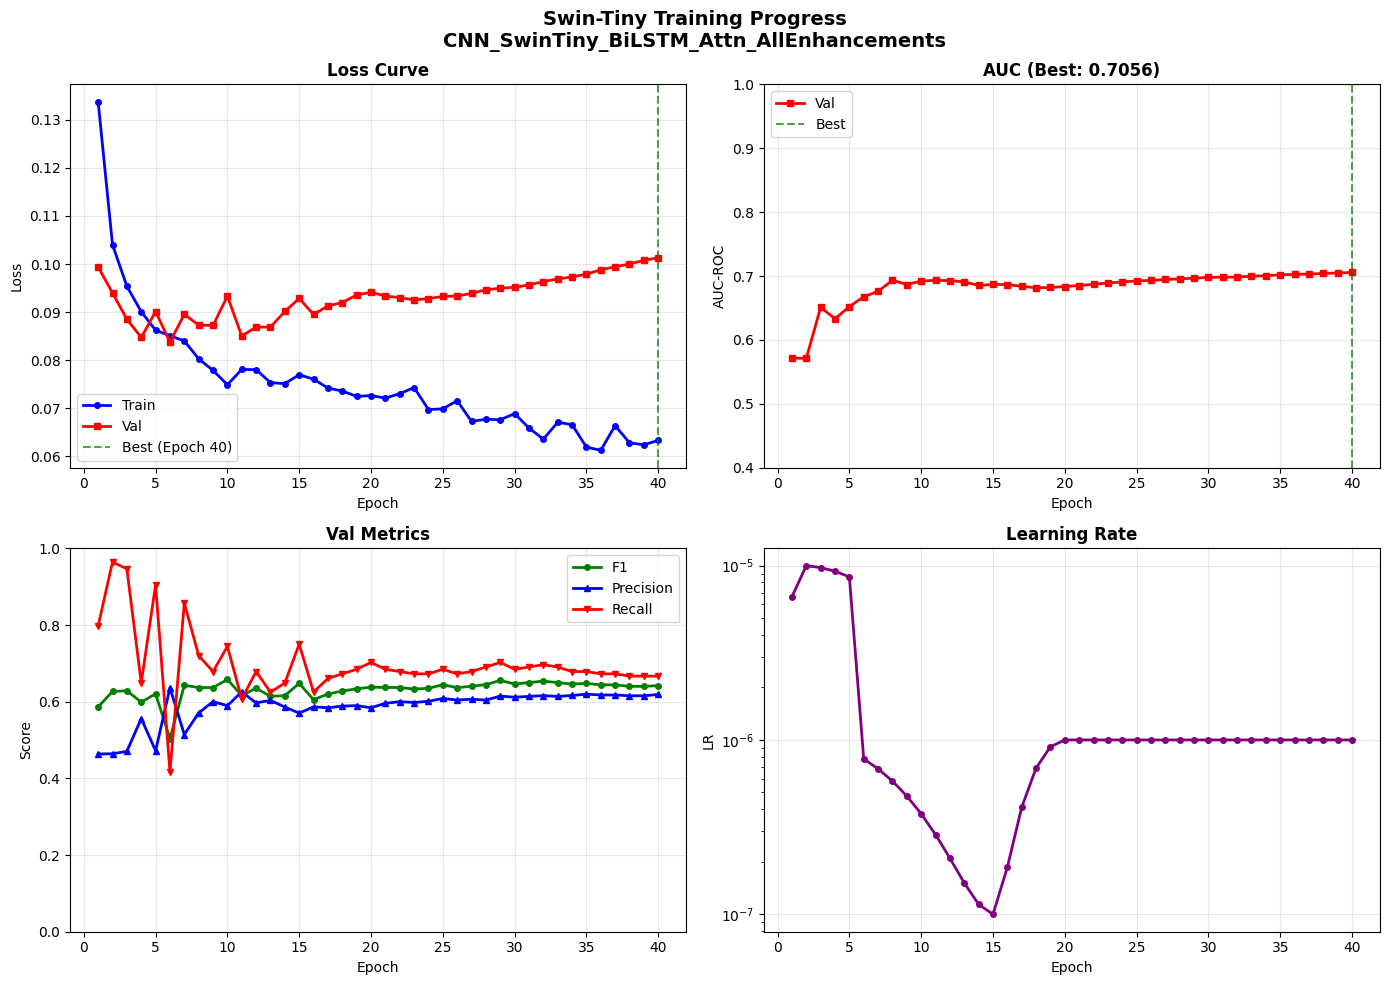

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES (Research-Grade Visualization)
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0,0].plot(epochs_range, history['train_loss'], 'b-o', label='Train', lw=2, ms=4)
axes[0,0].plot(epochs_range, history['val_loss'], 'r-s', label='Val', lw=2, ms=4)
axes[0,0].axvline(x=best_epoch, color='green', ls='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('Loss Curve', fontweight='bold'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs_range, history['val_auc'], 'r-s', label='Val', lw=2, ms=4)
axes[0,1].axvline(x=best_epoch, color='green', ls='--', alpha=0.7, label=f'Best')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('AUC-ROC')
axes[0,1].set_title(f'AUC (Best: {best_val_auc:.4f})', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3); axes[0,1].set_ylim([0.4, 1.0])

axes[1,0].plot(epochs_range, history['val_f1'], 'g-o', label='F1', lw=2, ms=4)
axes[1,0].plot(epochs_range, history['val_precision'], 'b-^', label='Precision', lw=2, ms=4)
axes[1,0].plot(epochs_range, history['val_recall'], 'r-v', label='Recall', lw=2, ms=4)
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Score')
axes[1,0].set_title('Val Metrics', fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3); axes[1,0].set_ylim([0, 1])

axes[1,1].plot(epochs_range, history['lr'], 'purple', marker='o', lw=2, ms=4)
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('LR')
axes[1,1].set_title('Learning Rate', fontweight='bold')
axes[1,1].set_yscale('log'); axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Swin-Tiny Training Progress\n{cfg.EXPERIMENT_NAME}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'training_curves_swin_fold{cfg.CURRENT_FOLD}.png'), dpi=200, bbox_inches='tight')
print("✓ Training curves saved")
plt.show()


## 6. Video-Level Inference & Export

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# LOAD BEST MODEL FOR INFERENCE
# ═══════════════════════════════════════════════════════════════════════════════

# Find best checkpoint
ckpt_path = os.path.join(cfg.OUTPUT_DIR, f"best_model_swin_fold{cfg.CURRENT_FOLD}.pth")
swa_path  = os.path.join(cfg.OUTPUT_DIR, f"swa_model_swin_fold{cfg.CURRENT_FOLD}.pth")

if os.path.exists(swa_path):
    model.load_state_dict(torch.load(swa_path, map_location=DEVICE))
    print(f"✓ Loaded SWA model: {swa_path}")
elif os.path.exists(ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f"✓ Loaded best model: {ckpt_path}")
else:
    print("⚠ No checkpoint found — using last epoch weights")

model.eval()
print(f"✓ Model ready for inference on {DEVICE}")

✓ Loaded SWA model: /kaggle/working/swa_model_swin_fold0.pth
✓ Model ready for inference on cuda


In [24]:
# Prediction functions defined in TTA cell below

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# 6-PASS TTA + VIDEO-LEVEL EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════
import torchvision.transforms.functional as TF

@torch.no_grad()
def predict_video_tta(model, frames_np, device, n_tta=6):
    """6-pass TTA: Standard, H-Flip, Bright+, Bright-, Blur, CenterCrop93%"""
    model.eval()
    all_probs = []
    targets = {f"image{i}": "image" for i in range(1, len(frames_np))}
    tf = A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        SafeToTensor(),
    ], additional_targets=targets)
    for tta_idx in range(n_tta):
        augmented = []
        for frame in frames_np:
            if tta_idx == 1:   frame = np.fliplr(frame).copy()
            elif tta_idx == 2: frame = np.clip(frame.astype(np.float32) * 1.15, 0, 255).astype(np.uint8)
            elif tta_idx == 3: frame = np.clip(frame.astype(np.float32) * 0.85, 0, 255).astype(np.uint8)
            elif tta_idx == 4: frame = cv2.GaussianBlur(frame, (3, 3), 0)
            elif tta_idx == 5:
                h, w = frame.shape[:2]
                crop_h, crop_w = int(h * 0.93), int(w * 0.93)
                y, x = (h - crop_h) // 2, (w - crop_w) // 2
                frame = cv2.resize(frame[y:y+crop_h, x:x+crop_w], (w, h))
            augmented.append(frame)

        data = {"image": augmented[0]}
        for i in range(1, len(augmented)):
            data[f"image{i}"] = augmented[i]

        transformed = tf(**data)
        tensors = [transformed["image"]] + [transformed[f"image{i}"] for i in range(1, len(augmented))]

        # Pad to max_frames
        actual = len(tensors)
        while len(tensors) < cfg.FRAMES_PER_VIDEO:
            tensors.append(torch.zeros_like(tensors[0]))

        frames_t = torch.stack(tensors[:cfg.FRAMES_PER_VIDEO]).unsqueeze(0).to(device)
        mask = torch.zeros(1, cfg.FRAMES_PER_VIDEO, dtype=torch.bool, device=device)
        mask[0, :actual] = True

        logits = model(frames_t, mask)
        prob = torch.sigmoid(logits).cpu().numpy()[0]
        all_probs.append(prob)
        del frames_t, mask

    return float(np.mean(all_probs))

# ── Run TTA on validation set ────────────────────────────────────────
print("Running 6-pass TTA on validation set...")
tta_results = []
for video in tqdm(val_videos, desc="TTA Inference"):
    vid_id = video["video_id"]
    if vid_id not in cache_index: continue

    faces = np.load(cache_index[vid_id])
    if len(faces) < 3: continue

    indices = np.linspace(0, len(faces)-1, min(len(faces), cfg.FRAMES_PER_VIDEO), dtype=int)
    selected = faces[indices]

    prob = predict_video_tta(model, selected, DEVICE, n_tta=6)

    tta_results.append({
        "video_id": vid_id, "label": video["label"],
        "P_CNN": prob, "prediction": int(prob >= 0.5),
        "source": video.get("source", "unknown")
    })
    del faces

tta_df = pd.DataFrame(tta_results)
tta_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "cnn_predictions_swin.csv"), index=False)
print(f"✓ TTA predictions saved: {len(tta_df)} videos")

# ── Compute metrics ──────────────────────────────────────────────────
y_true = tta_df["label"].values
y_prob = tta_df["P_CNN"].values
y_pred = (y_prob >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

auc  = roc_auc_score(y_true, y_prob)
acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)

print(f"\n{'='*60}")
print(f"FINAL RESULTS (6-pass TTA, threshold=0.5)")
print(f"{'='*60}")
print(f"  AUC-ROC:   {auc:.4f}")
print(f"  Accuracy:  {acc:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")

# ── Per-source AUC ───────────────────────────────────────────────────
if "source" in tta_df.columns:
    print(f"\n  Per-Source AUC Breakdown:")
    for src in sorted(tta_df["source"].unique()):
        subset = tta_df[tta_df["source"] == src]
        if len(subset["label"].unique()) < 2: continue
        try:
            src_auc = roc_auc_score(subset["label"], subset["P_CNN"])
            print(f"    {src:30s} AUC={src_auc:.4f} (n={len(subset)})")
        except: pass


Running 6-pass TTA on validation set...


TTA Inference:   0%|          | 0/367 [00:00<?, ?it/s]

✓ TTA predictions saved: 367 videos

FINAL RESULTS (6-pass TTA, threshold=0.5)
  AUC-ROC:   0.7089
  Accuracy:  0.6649
  F1-Score:  0.6476
  Precision: 0.6243
  Recall:    0.6726

  Per-Source AUC Breakdown:
    DFDC                           AUC=0.5397 (n=25)


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# BOOTSTRAP CONFIDENCE INTERVALS (Research-Grade)
# ═══════════════════════════════════════════════════════════════════════════════

from scipy.optimize import brentq
from scipy.interpolate import interp1d

def bootstrap_metric(y_true, y_score, metric_fn, n_boot=1000, ci=0.95):
    rng = np.random.RandomState(42); scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        yt, ys = y_true[idx], y_score[idx]
        if len(np.unique(yt)) < 2: continue
        try: scores.append(metric_fn(yt, ys))
        except: pass
    if not scores: return 0.0, 0.0, 0.0
    alpha = (1 - ci) / 2
    return np.mean(scores), np.percentile(scores, alpha*100), np.percentile(scores, (1-alpha)*100)

# FIX: Load from CSV if y_true not defined (e.g., if Cell 34 failed)
try:
    _ = y_true
except NameError:
    print("⚠️ y_true not found — loading from saved predictions CSV")
    csv_path = os.path.join(cfg.OUTPUT_DIR, "cnn_predictions_swin.csv")
    if os.path.exists(csv_path):
        tta_df = pd.read_csv(csv_path)
        y_true = tta_df["label"].values
        y_prob = tta_df["P_CNN"].values
        y_pred = (y_prob >= 0.5).astype(int)
        print(f"✓ Loaded {len(y_true)} predictions from {csv_path}")
    else:
        raise FileNotFoundError(f"Cannot find predictions at {csv_path}")

# Compute bootstrap CIs
auc_m, auc_lo, auc_hi = bootstrap_metric(y_true, y_prob, roc_auc_score)
acc_m, acc_lo, acc_hi = bootstrap_metric(y_true, y_pred, lambda t,p: accuracy_score(t,p))
f1_m, f1_lo, f1_hi   = bootstrap_metric(y_true, y_pred, lambda t,p: f1_score(t,p))
pre_m, pre_lo, pre_hi = bootstrap_metric(y_true, y_pred, lambda t,p: precision_score(t,p,zero_division=0))
rec_m, rec_lo, rec_hi = bootstrap_metric(y_true, y_pred, lambda t,p: recall_score(t,p,zero_division=0))

# EER
fpr, tpr, _ = roc_curve(y_true, y_prob)
try:
    eer = brentq(lambda x: 1.0 - x - interp1d(fpr, tpr)(x), 0., 1.)
except Exception:
    eer = 0.5

print(f"{'='*60}")
print(f"BOOTSTRAP 95% CONFIDENCE INTERVALS (n=1000)")
print(f"{'='*60}")
print(f"  AUC:       {auc_m:.4f} [{auc_lo:.4f}, {auc_hi:.4f}]")
print(f"  Accuracy:  {acc_m:.4f} [{acc_lo:.4f}, {acc_hi:.4f}]")
print(f"  F1:        {f1_m:.4f} [{f1_lo:.4f}, {f1_hi:.4f}]")
print(f"  Precision: {pre_m:.4f} [{pre_lo:.4f}, {pre_hi:.4f}]")
print(f"  Recall:    {rec_m:.4f} [{rec_lo:.4f}, {rec_hi:.4f}]")
print(f"  EER:       {eer:.4f}")

BOOTSTRAP 95% CONFIDENCE INTERVALS (n=1000)
  AUC:       0.7089 [0.6555, 0.7558]
  Accuracy:  0.6653 [0.6158, 0.7139]
  F1:        0.6472 [0.5911, 0.7042]
  Precision: 0.6257 [0.5586, 0.6961]
  Recall:    0.6715 [0.6057, 0.7445]
  EER:       0.3417


✓ Evaluation plots saved

              precision    recall  f1-score   support

        Real     0.7043    0.6583    0.6805       199
        Fake     0.6243    0.6726    0.6476       168

    accuracy                         0.6649       367
   macro avg     0.6643    0.6655    0.6640       367
weighted avg     0.6677    0.6649    0.6654       367



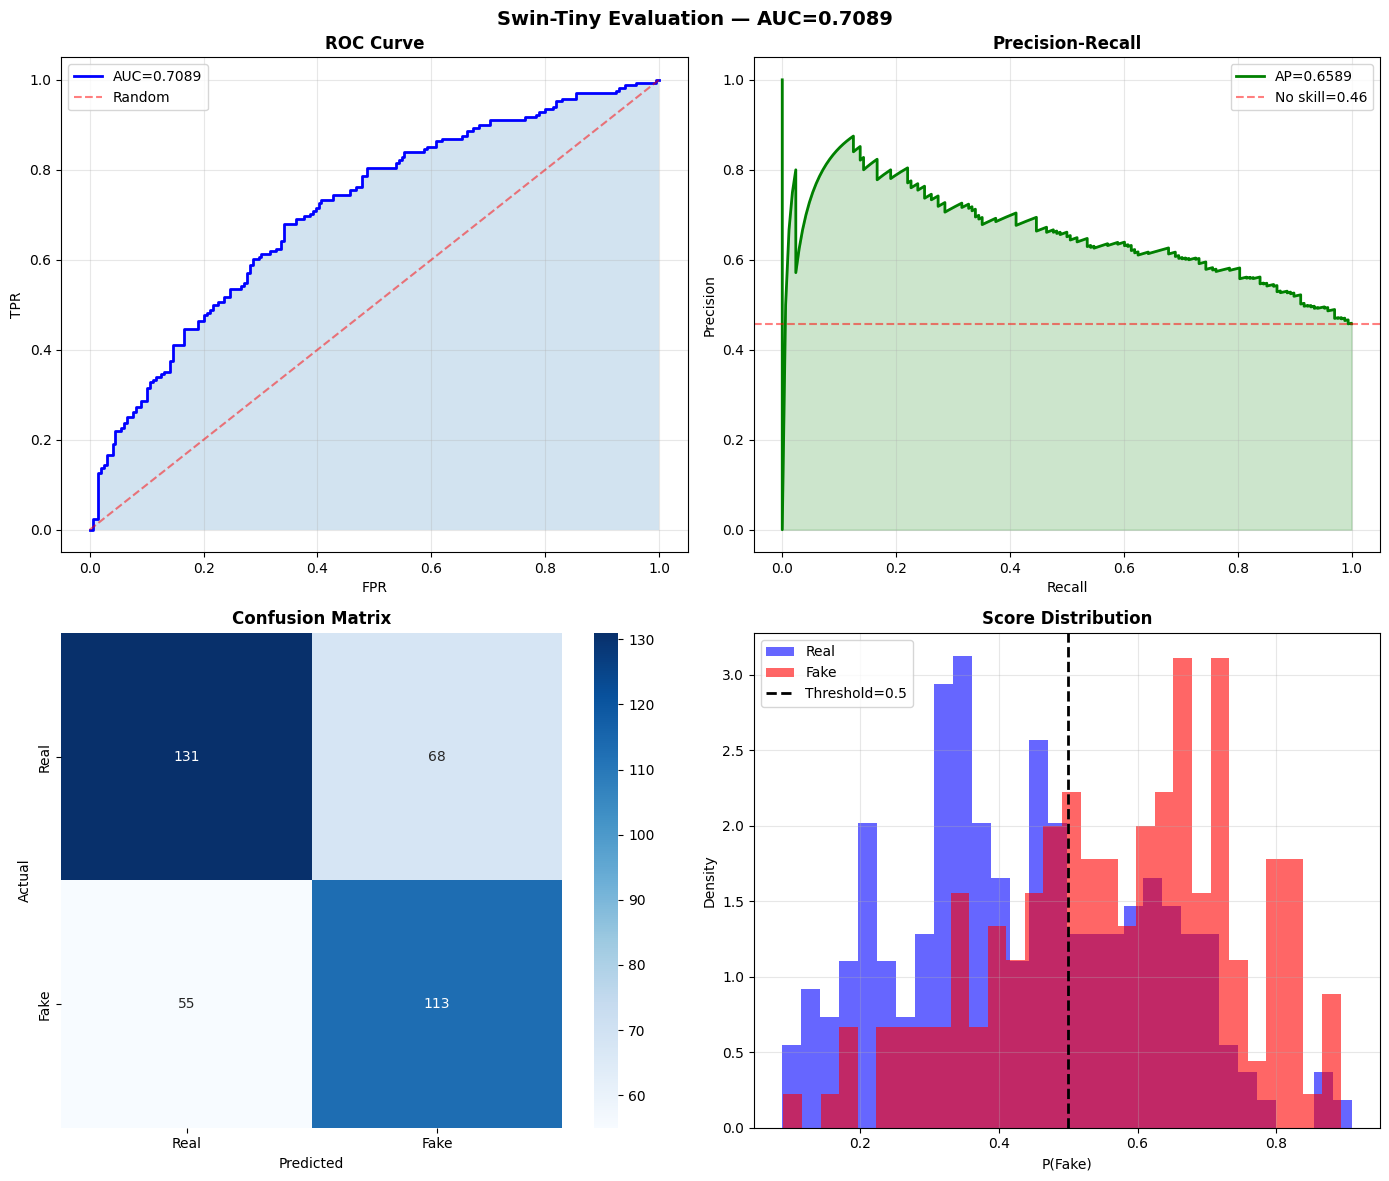

In [27]:
# ═══════════════════════════════════════════════════════════════════════════════
# EVALUATION PLOTS (ROC, PR, Confusion Matrix, Score Distribution)
# ═══════════════════════════════════════════════════════════════════════════════

import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[0,0].plot(fpr, tpr, 'b-', lw=2, label=f'AUC={auc:.4f}')
axes[0,0].fill_between(fpr, tpr, alpha=0.2)
axes[0,0].plot([0,1],[0,1],'r--',alpha=0.5, label='Random')
axes[0,0].set_xlabel('FPR'); axes[0,0].set_ylabel('TPR')
axes[0,0].set_title('ROC Curve', fontweight='bold'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# 2. Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)
axes[0,1].plot(recall_arr, precision_arr, 'g-', lw=2, label=f'AP={ap:.4f}')
axes[0,1].fill_between(recall_arr, precision_arr, alpha=0.2, color='green')
baseline = y_true.sum()/len(y_true)
axes[0,1].axhline(y=baseline, color='r', ls='--', alpha=0.5, label=f'No skill={baseline:.2f}')
axes[0,1].set_xlabel('Recall'); axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision-Recall', fontweight='bold'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Actual')
axes[1,0].set_title('Confusion Matrix', fontweight='bold')

# 4. Score Distribution
axes[1,1].hist(y_prob[y_true==0], bins=30, alpha=0.6, color='blue', label='Real', density=True)
axes[1,1].hist(y_prob[y_true==1], bins=30, alpha=0.6, color='red', label='Fake', density=True)
axes[1,1].axvline(x=0.5, color='black', ls='--', lw=2, label='Threshold=0.5')
axes[1,1].set_xlabel('P(Fake)'); axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Score Distribution', fontweight='bold'); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle(f'Swin-Tiny Evaluation — AUC={auc:.4f}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, f'evaluation_swin_fold{cfg.CURRENT_FOLD}.png'), dpi=200, bbox_inches='tight')
print("✓ Evaluation plots saved")

# Classification report
print("\n" + classification_report(y_true, y_pred, target_names=["Real","Fake"], digits=4))
plt.show()

⚠ Grad-CAM error: too many values to unpack (expected 2)


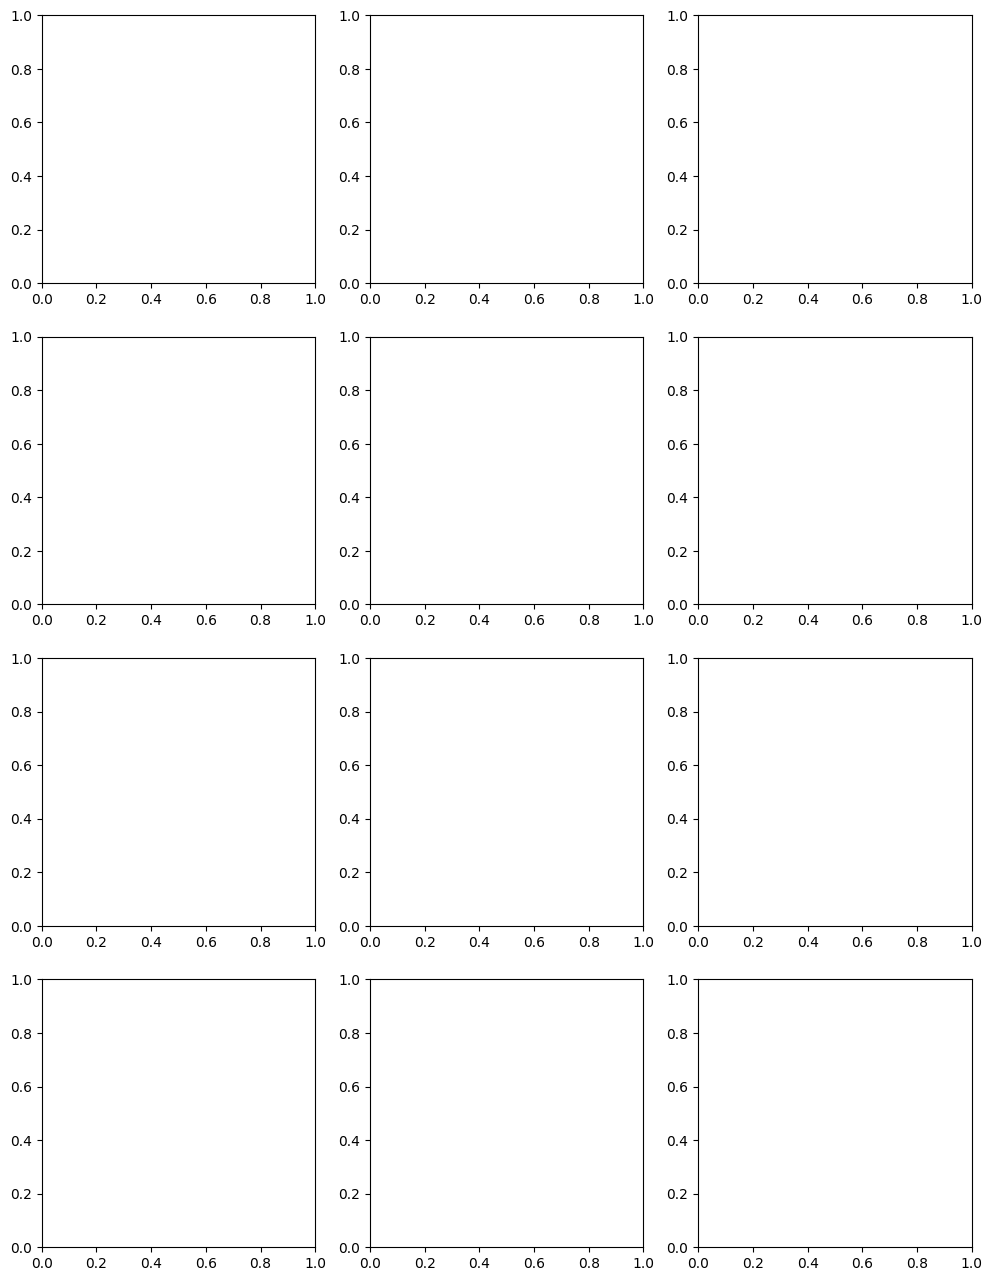

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# GRAD-CAM FOR SWIN TRANSFORMER (Reshape 1D → 2D)
# ═══════════════════════════════════════════════════════════════════════════════

class SwinGradCAM:
    """Grad-CAM adapted for Swin Transformer — reshapes sequence back to spatial grid."""
    def __init__(self, model, target_layer=None):
        self.model = model
        # Target the final LayerNorm of the last Swin block
        if target_layer is None:
            self.target_layer = model.backbone.layers[-1].blocks[-1].norm1
        else:
            self.target_layer = target_layer
        self.gradients = None; self.activations = None
        self.target_layer.register_forward_hook(self._forward_hook)
        self.target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output): self.activations = output.detach()
    def _backward_hook(self, module, grad_in, grad_out): self.gradients = grad_out[0].detach()

    def generate(self, frames_tensor, mask_tensor):
        self.model.eval()
        frames_tensor.requires_grad_(True)
        logits = self.model(frames_tensor, mask_tensor)
        self.model.zero_grad()
        logits.backward(retain_graph=True)
        del logits

        if self.gradients is None or self.activations is None:
            return None

        # activations shape: (B*T, num_patches, C) for Swin
        grads = self.gradients  # (B*T, L, C)
        acts  = self.activations  # (B*T, L, C)

        weights = grads.mean(dim=1, keepdim=True)  # (B*T, 1, C)
        cam = (weights * acts).sum(dim=-1)  # (B*T, L)
        cam = F.relu(cam)

        # Reshape from sequence to spatial grid
        # Swin-Tiny at 224px: 7×7 = 49 patches at final stage
        B_T, L = cam.shape
        h = w = int(L ** 0.5)
        if h * w != L:
            h = w = 7  # Swin-Tiny default
            cam = cam[:, :h*w]

        cam = cam.view(B_T, 1, h, w)
        cam = F.interpolate(cam, size=(cfg.IMG_SIZE, cfg.IMG_SIZE), mode='bilinear', align_corners=False)
        cam = cam.squeeze(1)

        # Normalize per-image
        cam_min = cam.flatten(1).min(dim=1, keepdim=True)[0].unsqueeze(-1)
        cam_max = cam.flatten(1).max(dim=1, keepdim=True)[0].unsqueeze(-1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.cpu().numpy()

# ── Generate Grad-CAM visualizations ──────────────────────────────────
try:
    gradcam = SwinGradCAM(model)
    n_samples = min(4, len(val_dataset))
    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4*n_samples))
    if n_samples == 1: axes = axes[np.newaxis, :]

    for i in range(n_samples):
        sample = val_dataset[i]
        frames = sample["frames"].unsqueeze(0).to(DEVICE)
        mask = sample["mask"].unsqueeze(0).to(DEVICE)

        cam = gradcam.generate(frames.clone(), mask)
        if cam is None: continue

        # Show first frame
        orig = frames[0, 0].cpu().numpy().transpose(1, 2, 0)
        orig = (orig * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
        orig = np.clip(orig, 0, 1)

        axes[i, 0].imshow(orig); axes[i, 0].set_title(f"Original (label={sample['label'].item():.0f})")
        axes[i, 0].axis('off')

        heatmap = cam[0]
        axes[i, 1].imshow(heatmap, cmap='jet'); axes[i, 1].set_title("Grad-CAM Heatmap")
        axes[i, 1].axis('off')

        overlay = orig * 0.5 + plt.cm.jet(heatmap)[:,:,:3] * 0.5
        axes[i, 2].imshow(np.clip(overlay, 0, 1)); axes[i, 2].set_title("Overlay")
        axes[i, 2].axis('off')

        del frames, mask, cam

    plt.suptitle("Swin-Tiny Grad-CAM Attention Visualization", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, "gradcam_swin.png"), dpi=150, bbox_inches='tight')
    print("✓ Grad-CAM saved")
    plt.show()
except Exception as e:
    print(f"⚠ Grad-CAM error: {e}")

## 7. Late Fusion Integration Guide

In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# LATE FUSION INTEGRATION GUIDE
# ═══════════════════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    LATE FUSION INTEGRATION                          ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  This notebook produces: cnn_predictions_swin.csv                   ║
║  Columns: video_id, label, P_CNN, prediction, source                ║
║                                                                      ║
║  To integrate with other streams:                                   ║
║                                                                      ║
║  1. EfficientNet stream → cnn_predictions_efficientnet.csv          ║
║  2. Xception stream     → cnn_predictions_xception.csv              ║
║  3. Swin stream         → cnn_predictions_swin.csv (this notebook)  ║
║  4. rPPG stream         → rppg_predictions.csv                      ║
║                                                                      ║
║  Fusion formula:                                                     ║
║  P_final = w1*P_eff + w2*P_xception + w3*P_swin + w4*P_rppg        ║
║  where w1+w2+w3+w4 = 1.0                                            ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# Verify output file
csv_path = os.path.join(cfg.OUTPUT_DIR, "cnn_predictions_swin.csv")
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"✓ Output file exists: {csv_path}")
    print(f"  Videos: {len(df)} | Columns: {list(df.columns)}")
    print(f"  P_CNN range: [{df['P_CNN'].min():.4f}, {df['P_CNN'].max():.4f}]")
else:
    print("⚠ Output file not yet generated — run training first")


╔══════════════════════════════════════════════════════════════════════╗
║                    LATE FUSION INTEGRATION                          ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  This notebook produces: cnn_predictions_swin.csv                   ║
║  Columns: video_id, label, P_CNN, prediction, source                ║
║                                                                      ║
║  To integrate with other streams:                                   ║
║                                                                      ║
║  1. EfficientNet stream → cnn_predictions_efficientnet.csv          ║
║  2. Xception stream     → cnn_predictions_xception.csv              ║
║  3. Swin stream         → cnn_predictions_swin.csv (this notebook)  ║
║  4. rPPG stream         → rppg_predictions.csv                      ║
║                                                         

In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("SWIN-TINY DEEPFAKE DETECTION — COMPLETE")
print("=" * 70)
print(f"  Backbone:     {cfg.MODEL_NAME}")
print(f"  Best AUC:     {best_val_auc:.4f} (epoch {best_epoch})")
print(f"  Predictions:  cnn_predictions_swin.csv")
print(f"  Checkpoint:   best_model_swin_fold{cfg.CURRENT_FOLD}.pth")
print("=" * 70)

SWIN-TINY DEEPFAKE DETECTION — COMPLETE
  Backbone:     swin_tiny_patch4_window7_224
  Best AUC:     0.7056 (epoch 40)
  Predictions:  cnn_predictions_swin.csv
  Checkpoint:   best_model_swin_fold0.pth


## 📋 5-Fold Cross-Validation Instructions (For Publication)

To report mean ± std metrics, run this notebook 5 times:
1. Set `cfg.CURRENT_FOLD = 0` → run all cells → collect results
2. Set `cfg.CURRENT_FOLD = 1` → restart + run → collect
3. Repeat for folds 2, 3, 4

Then compute: `AUC = mean(fold_aucs) ± std(fold_aucs)`